# PM10 Air Quality Forecasting — Lombardy

**Project summary notebook** — an end-to-end overview of the pipeline: data collection,
feature engineering, EDA, regression and classification models, and a live forecast demo
through the REST API.

---

## Section 1 — Introduction

### Objective

Forecast the daily mean **PM10** concentration (µg/m³) and the corresponding **alert class**
for the 67 ARPA monitoring stations in Lombardy, with a 1–2 day horizon.

Alert classes follow the daily PM10 thresholds:

| Class | PM10 range |
|---|---|
| 🟢 verde | < 20 µg/m³ |
| 🟡 giallo | 20 – 35 µg/m³ |
| 🟠 arancio | 35 – 50 µg/m³ |
| 🔴 rosso | ≥ 50 µg/m³ |

### Data sources

| Source | Content | Role |
|---|---|---|
| **ARPA Lombardia** (Socrata Open Data) | Validated PM10 measurements (daily), NO₂/O₃ (hourly), sensor registry | Target + pollutant covariates |
| **Open-Meteo** (historical forecast API) | Hourly weather: temperature, humidity, wind, pressure, precipitation, boundary layer height, ... | Meteorological covariates |
| **OpenStreetMap** | Industrial zones (landuse=industrial) | Spatial feature `dist_industrial_km` |

Coverage: **2024-01-01 → 2026-05-07**, 67 stations, ~54,600 (station, day) rows.

### Pipeline

```
[ARPA Lombardia API]  [Open-Meteo API]  [OpenStreetMap]
        │                    │                 │
        └────────────────────┴─────────────────┘
                             │
                    Step 1: Collection
                  (JSON blobs → data/raw/)
                             │
                    Step 2: Ingestion
              (JSON → MySQL: measurements,
               weather_hourly, stations, sensors)
               + industrial_proximity.parquet
                             │
                    Step 3: EDA + Feature Engineering
                  (MySQL → daily_dataset_clean.parquet)
                  (RMT spectral diagnostic)
                             │
              ┌──────────────┼──────────────┐
              │              │              │
         Step 4:         Step 5:       Step 6:
       Regression     Classification  Clustering
          │               │              │
     regression_      classification_  clustering_
     metrics.json     metrics.json    metrics.json
          │               │
          └───────────────┘
                    │
               FastAPI App
         (predictor.py loads .joblib)
         (recent_data.py reads GCS)
                    │
           [Google Cloud Run]
```

In [1]:
# Setup — run this notebook from the project root, with the API up on localhost:8000
import json
import sys
from datetime import date, timedelta
from pathlib import Path

import pandas as pd
import requests
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
assert (ROOT / "step_3_eda").exists(), "Run the notebook from the project root."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

API_BASE = "http://127.0.0.1:8000"
PARQUET_PATH = ROOT / "step_3_eda" / "daily_dataset_clean.parquet"
EDA_PLOTS_DIR = ROOT / "step_3_eda" / "plots"
REG_METRICS = ROOT / "step_4_regression" / "artifacts" / "regression_metrics.json"
REG_PLOTS_DIR = ROOT / "step_4_regression" / "artifacts" / "plots"
CLS_METRICS = ROOT / "step_5_classification" / "artifacts" / "classification_metrics.json"
CLS_SELECTION = ROOT / "step_5_classification" / "artifacts" / "final_model_selection.json"
CLS_PLOTS_DIR = ROOT / "step_5_classification" / "artifacts" / "plots"

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


def show_plot(path: Path, width: int = 900) -> None:
    display(Markdown(f"**{path.name}**"))
    display(Image(filename=str(path), width=width))


print("Setup OK — project root:", ROOT)

Setup OK — project root: C:\Users\marco\Desktop\DataScience_ExamProject


## Section 2 — Data Collection

**Step 1** (`step_1_collection/collector.py`) downloads every day:

- **validated ARPA measurements** (`stato='VA'`) from the Socrata endpoint `nicp-bhqi` —
  PM10/PM2.5 as one daily value, NO₂/O₃/CO as hourly values;
- **hourly Open-Meteo weather** (historical forecast API) for each station's grid cell.

Raw JSON blobs are archived in `data/raw/` (immutable training store) and on a GCS bucket
(rolling window used at serving time). The next cells run a small live fetch as an example.

In [2]:
from step_1_collection.collector import fetch_arpa_measurements, fetch_station_weather_historical

# Recent, but far back enough for ARPA to have validated the measurements
sample_date = (date.today() - timedelta(days=10)).isoformat()

measurements = fetch_arpa_measurements(sample_date)
print(f"ARPA {sample_date}: {len(measurements)} validated records. First 2 records:")
print(json.dumps(measurements[:2], indent=2, ensure_ascii=False))

ARPA 2026-06-26: 7242 validated records. First 2 records:
[
  {
    "idsensore": "9875",
    "data": "2026-06-26T00:00:00.000",
    "valore": "12.5",
    "stato": "VA",
    "idoperatore": "1"
  },
  {
    "idsensore": "10001",
    "data": "2026-06-26T00:00:00.000",
    "valore": "15.0",
    "stato": "VA",
    "idoperatore": "1"
  }
]


In [3]:
# Open-Meteo weather for the Sondrio station grid cell (station 1264)
weather = fetch_station_weather_historical(lat="46.167", lng="9.883", date_str=sample_date)

hourly = weather["hourly"]
print(f"Open-Meteo {sample_date} — hourly variables: {list(hourly.keys())}")
preview = {k: v[:4] for k, v in hourly.items() if k in ("time", "temperature_2m", "wind_speed_10m", "boundary_layer_height")}
print(json.dumps(preview, indent=2))

Open-Meteo 2026-06-26 — hourly variables: ['time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'visibility', 'shortwave_radiation', 'boundary_layer_height']
{
  "time": [
    "2026-06-26T00:00",
    "2026-06-26T01:00",
    "2026-06-26T02:00",
    "2026-06-26T03:00"
  ],
  "temperature_2m": [
    23.5,
    22.1,
    22.1,
    22.1
  ],
  "wind_speed_10m": [
    1.8,
    9.0,
    5.4,
    1.8
  ],
  "boundary_layer_height": [
    105.0,
    110.0,
    20.0,
    40.0
  ]
}


## Section 3 — Feature Engineering

**Step 3** (`step_3_eda/build_dataset.py`) builds the daily dataset
`daily_dataset_clean.parquet` from MySQL (one row per station/day pair, ~50 features).

### Temporal features

| Feature | Description |
|---|---|
| `mese`, `stagione`, `giorno_settimana`, `is_weekend` | Basic calendar |
| `heating_season` | 1 in October–March (domestic heating) |
| `mese_sin/cos`, `dow_sin/cos` | Cyclic encoding of month and day of week |

### Lag / rolling features

| Feature | Description |
|---|---|
| `pm10_lag1`, `pm10_lag2` | PM10 one / two days before |
| `pm10_roll3`, `pm10_roll7` | 3-day and 7-day rolling means |
| `pm10_diff` | Day-over-day change (lag1 − lag2) |
| `pressure_mean_lag1`, `wind_speed_mean_lag1/2`, `blh_mean_lag1/2`, `temp_mean_lag1/2` | Weather lags (persistence of anticyclonic regimes) |
| `pressure_roll3`, `wind_speed_roll3` | 3-day weather rolling means |

### Derived weather features

| Feature | Description |
|---|---|
| `stagnation_flag` | 1 if high pressure ∧ weak wind ∧ shallow boundary layer |
| `stagnation_index` | `1 / (wind_speed_mean × blh_min × (1 + precip_sum))` — the atmosphere's capacity to trap pollutants |
| `fog_hours` | Hours of reduced visibility in the day |

### Spatial / static features

| Feature | Description |
|---|---|
| `lat`, `lng`, `quota`, `provincia` | Station location and orography |
| `dist_industrial_km` | Distance to the nearest OSM industrial zone |

### Why cyclic encoding?

Month and day of week are **circular** variables: December (12) and January (1) are
atmospherically contiguous, yet as integers they are as far apart as possible. The pair
`sin(2π·m/12), cos(2π·m/12)` represents them as nearby points on the unit circle, avoiding
ordinal artefacts in both linear models and tree splits.

In [4]:
df = pd.read_parquet(PARQUET_PATH)
engineered = [
    "idstazione", "data_giorno", "pm10", "classe_allerta",
    "pm10_lag1", "pm10_roll7", "mese_sin", "mese_cos",
    "heating_season", "stagnation_index", "dist_industrial_km",
]
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns — sample of engineered features:")
df[engineered].tail(5)

Dataset: 54,595 rows x 52 columns — sample of engineered features:


,idstazione,data_giorno,pm10,classe_allerta,pm10_lag1,pm10_roll7,mese_sin,mese_cos,heating_season,stagnation_index,dist_industrial_km
54590,709,2026-05-03,12.000,verde,20.000,19.429,0.500,-0.866,0,0.007,0.595
54591,709,2026-05-04,13.000,verde,12.000,18.571,0.500,-0.866,0,0.002,0.595
54592,709,2026-05-05,12.000,verde,13.000,17.857,0.500,-0.866,0,0.002,0.595
54593,709,2026-05-06,14.000,verde,12.000,16.571,0.500,-0.866,0,0.000,0.595
54594,709,2026-05-07,6.000,verde,14.000,15.286,0.500,-0.866,0,0.005,0.595


## Section 4 — EDA

Essential dataset statistics and the 16 exploratory plots produced by Step 3
(`step_3_eda/plots/`): 13 core EDA plots plus 3 from the **Random Matrix Theory (RMT)
spectral diagnostic** (plots 14–16). Key findings:

- strong PM10 **autocorrelation** (`corr(pm10, pm10_lag1) ≈ 0.79`) → lags are the dominant predictors;
- strong **seasonality**: winter PM10 ≈ 2× summer (heating + thermal inversions);
- **weather drivers**: wind, boundary layer height and precipitation anti-correlated with PM10; pressure positively correlated;
- **non-Gaussian target** (skew ≈ 1.71, kurtosis ≈ 5.64) → log-transform in regression, class weights in classification;
- **province-level heterogeneity**: Bergamo/Brescia/Cremona more polluted, pre-Alpine stations cleaner;
- **RMT diagnostic**: of 41 numeric features, 9 eigenvalues exceed the Marchenko–Pastur bound
  (λ⁺ ≈ 1.056) and carry ~74% of the variance — real structure well above the noise floor.

In [5]:
stats = pd.DataFrame({
    "value": {
        "rows (station-day)": f"{len(df):,}",
        "stations": df["idstazione"].nunique(),
        "period": f"{df['data_giorno'].min().date()} -> {df['data_giorno'].max().date()}",
        "PM10 mean (ug/m3)": round(float(df["pm10"].mean()), 2),
        "PM10 median (ug/m3)": round(float(df["pm10"].median()), 2),
        "PM10 skew": round(float(df["pm10"].skew()), 2),
        "PM10 kurtosis": round(float(df["pm10"].kurtosis()), 2),
    }
})
display(stats)
df["classe_allerta"].value_counts(normalize=True).round(3).to_frame("alert class share")

,value
rows (station-day),"54,595"
stations,67
period,2024-01-01 -> 2026-05-07
PM10 mean (ug/m3),26.920
PM10 median (ug/m3),22.000
PM10 skew,1.750
PM10 kurtosis,5.900


,alert class share
classe_allerta,
verde,0.423
giallo,0.318
arancio,0.151
rosso,0.108


**01_missing_values_heatmap.png**

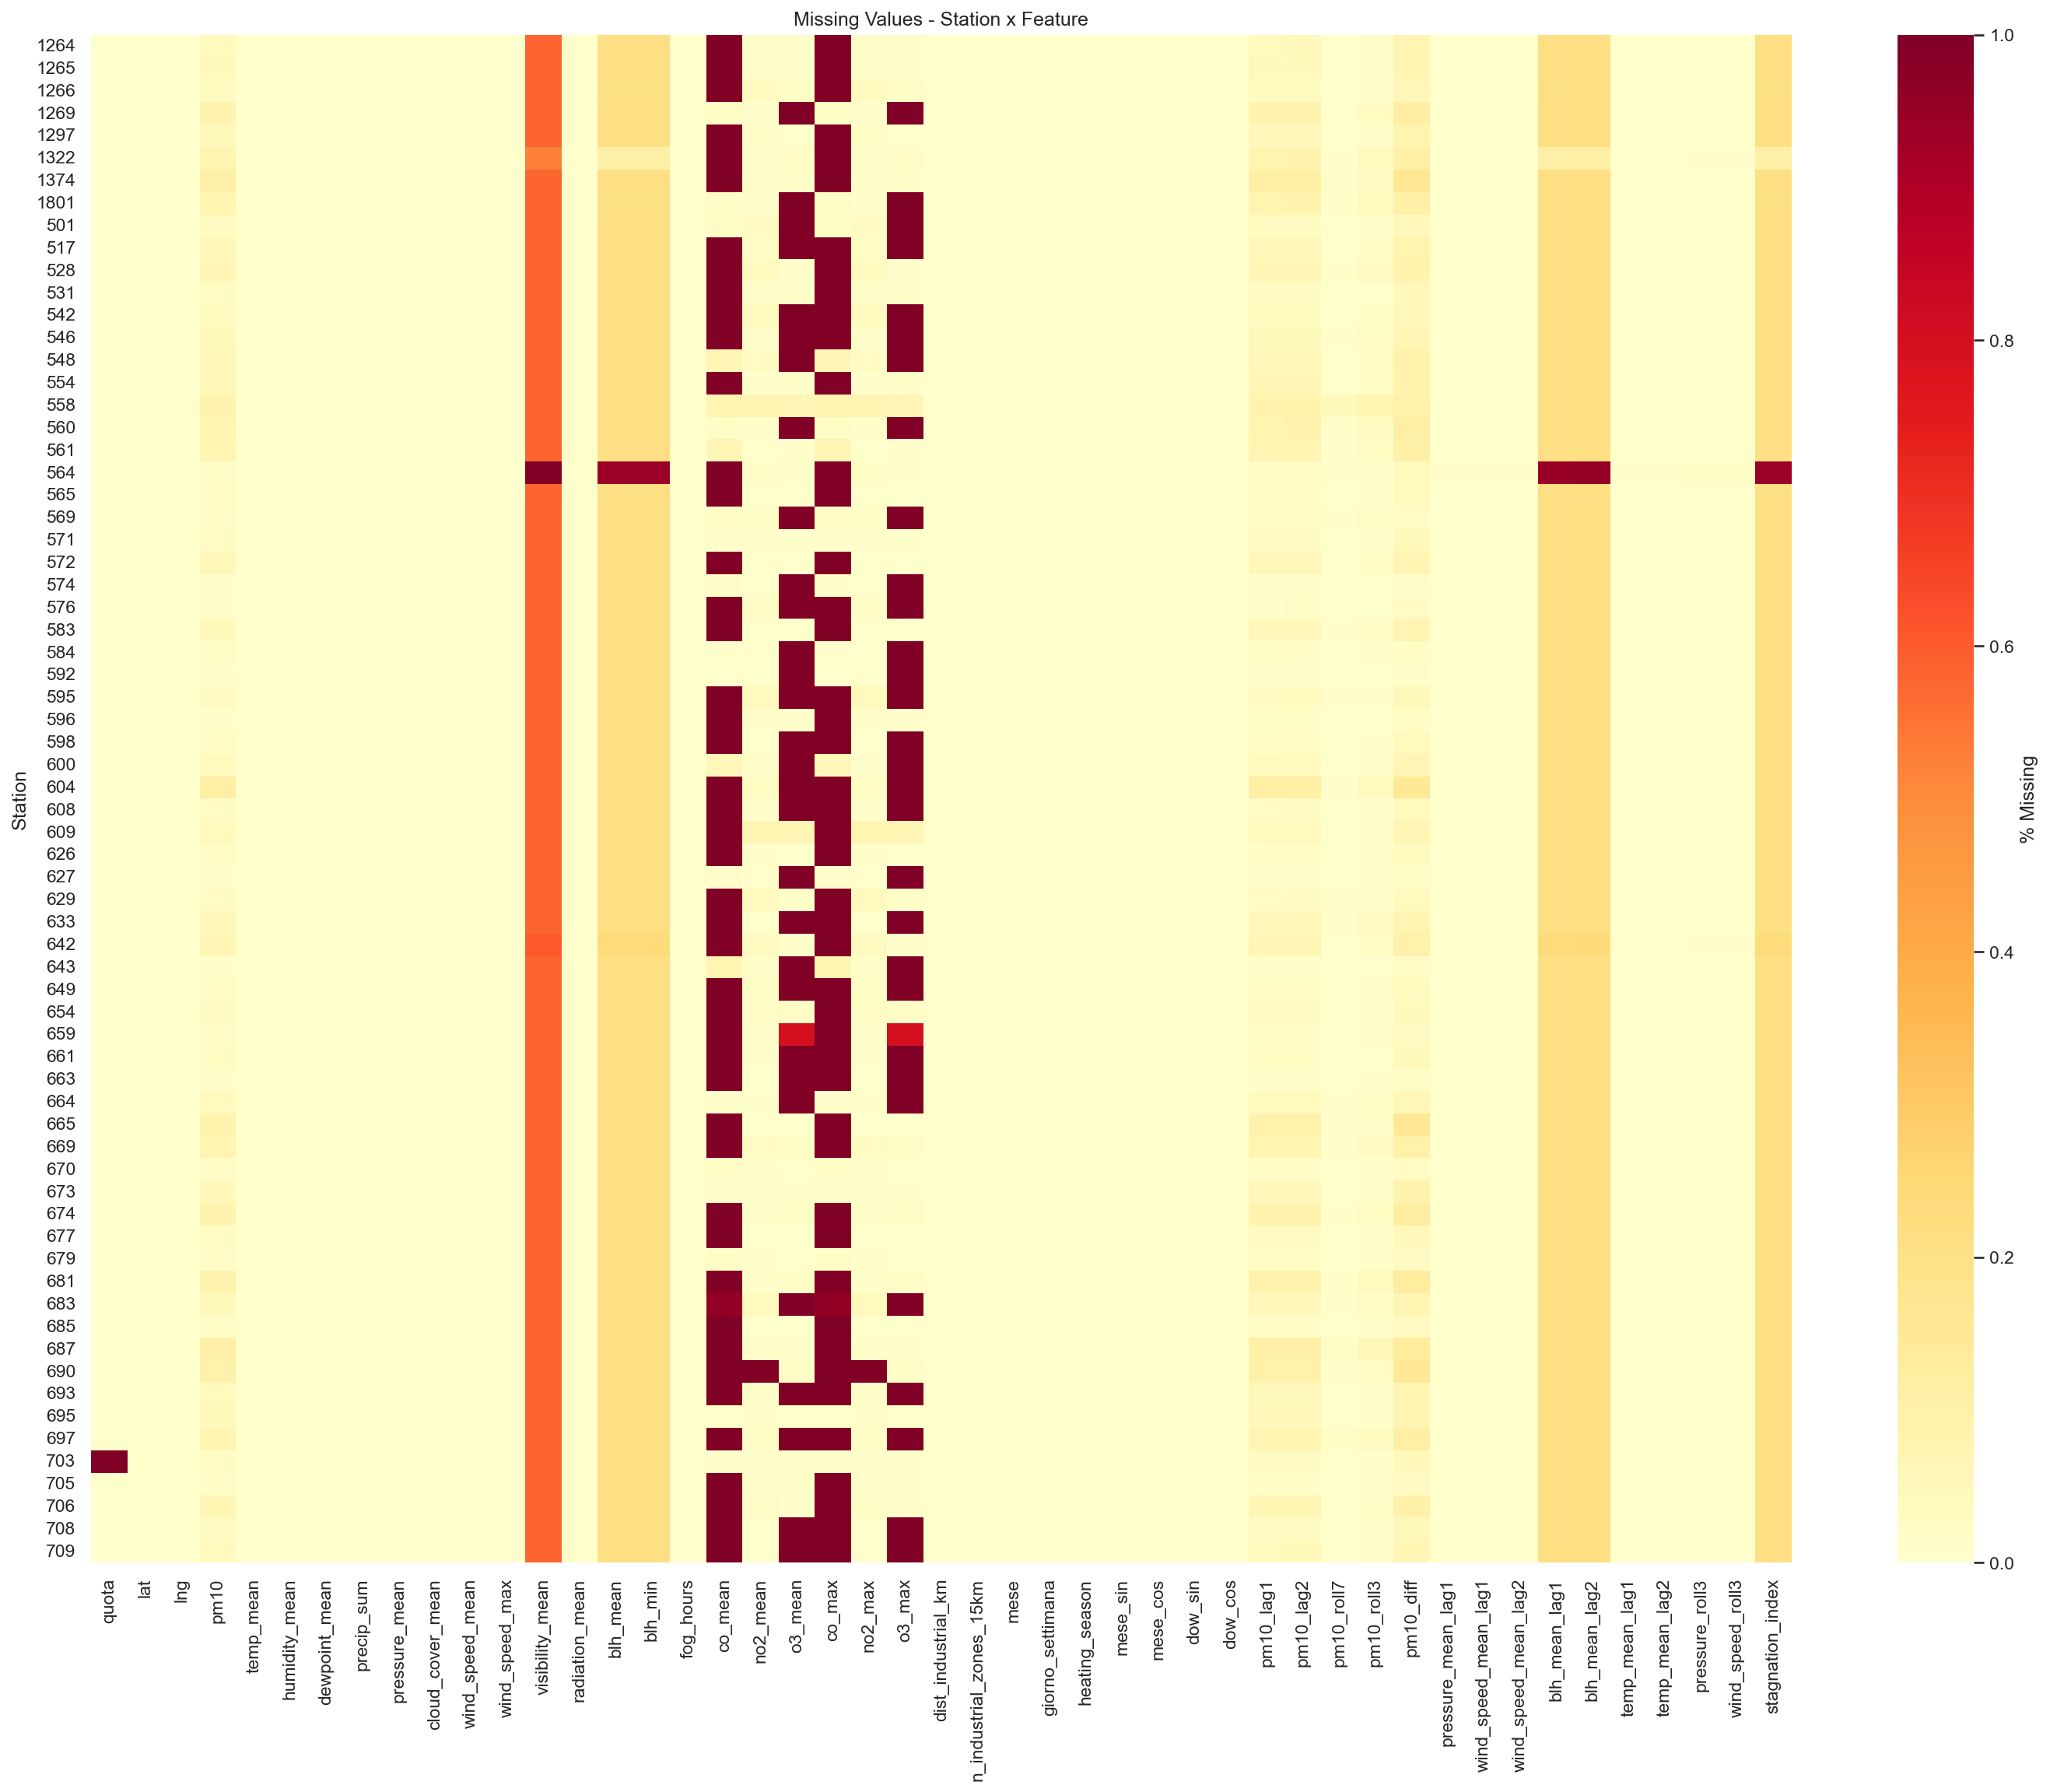

**02_pm10_distribution.png**

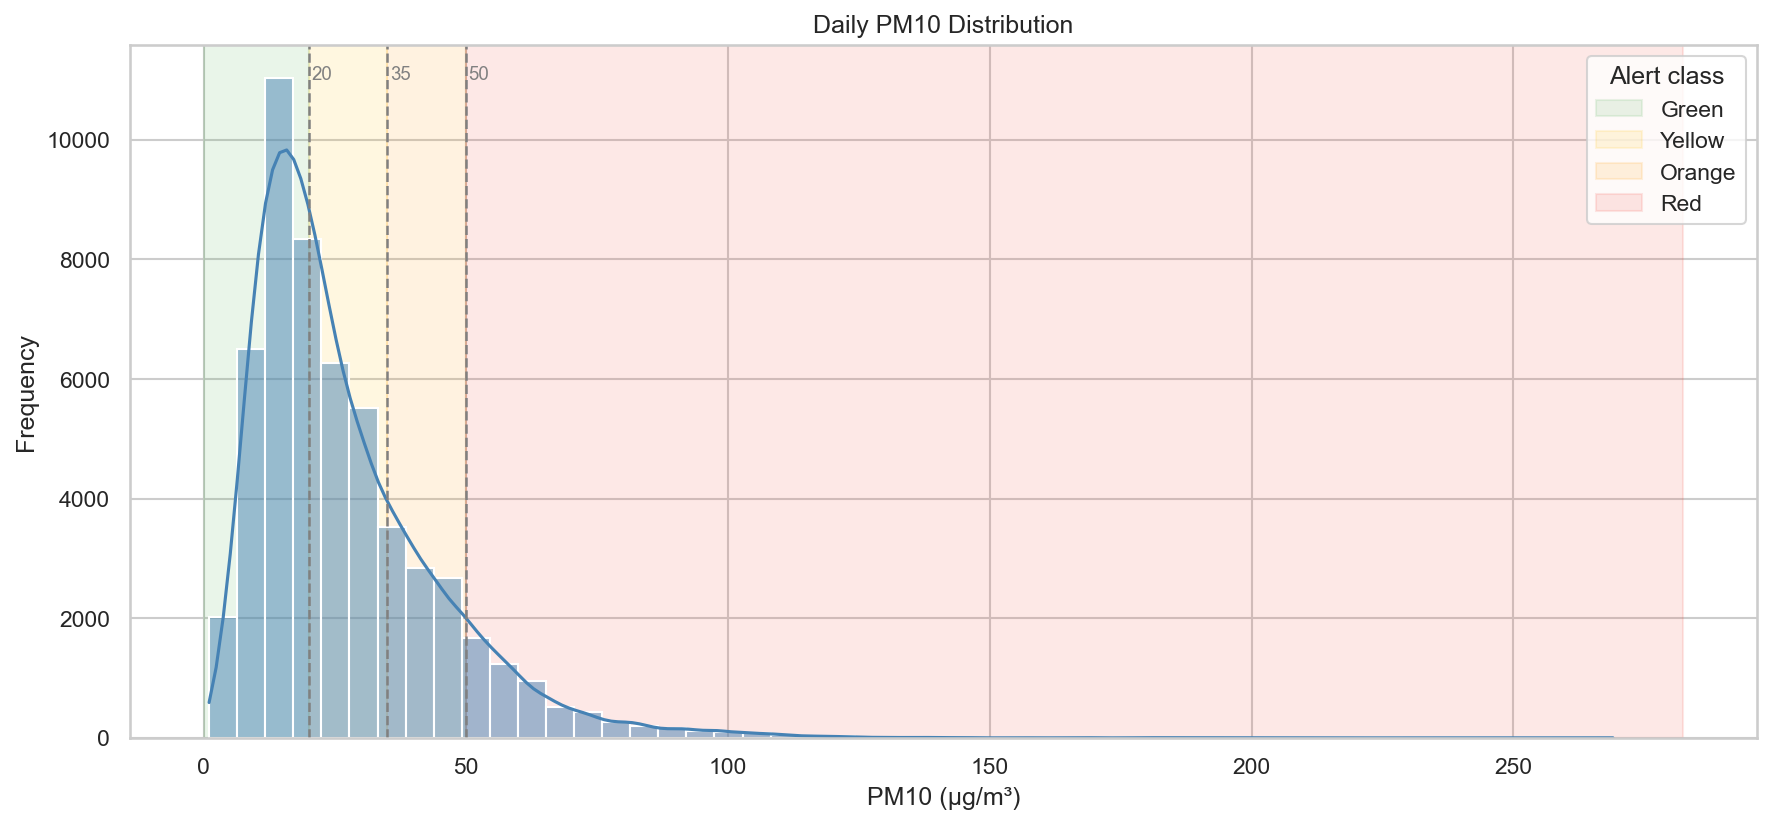

**03_class_distribution.png**

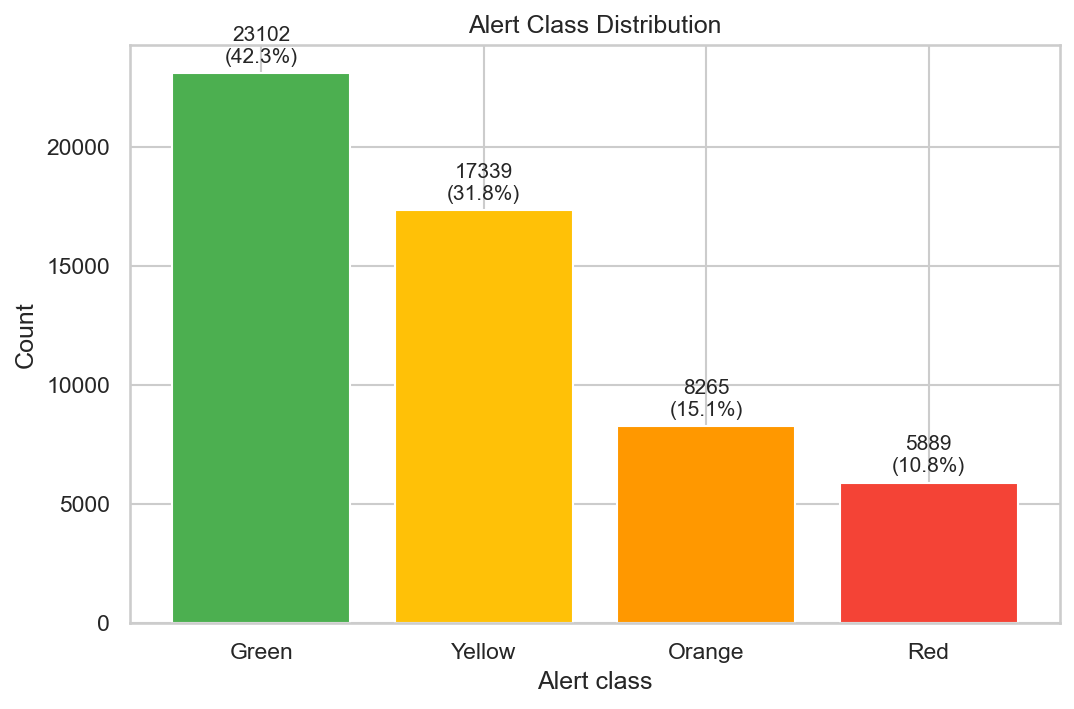

**04_correlation_heatmap.png**

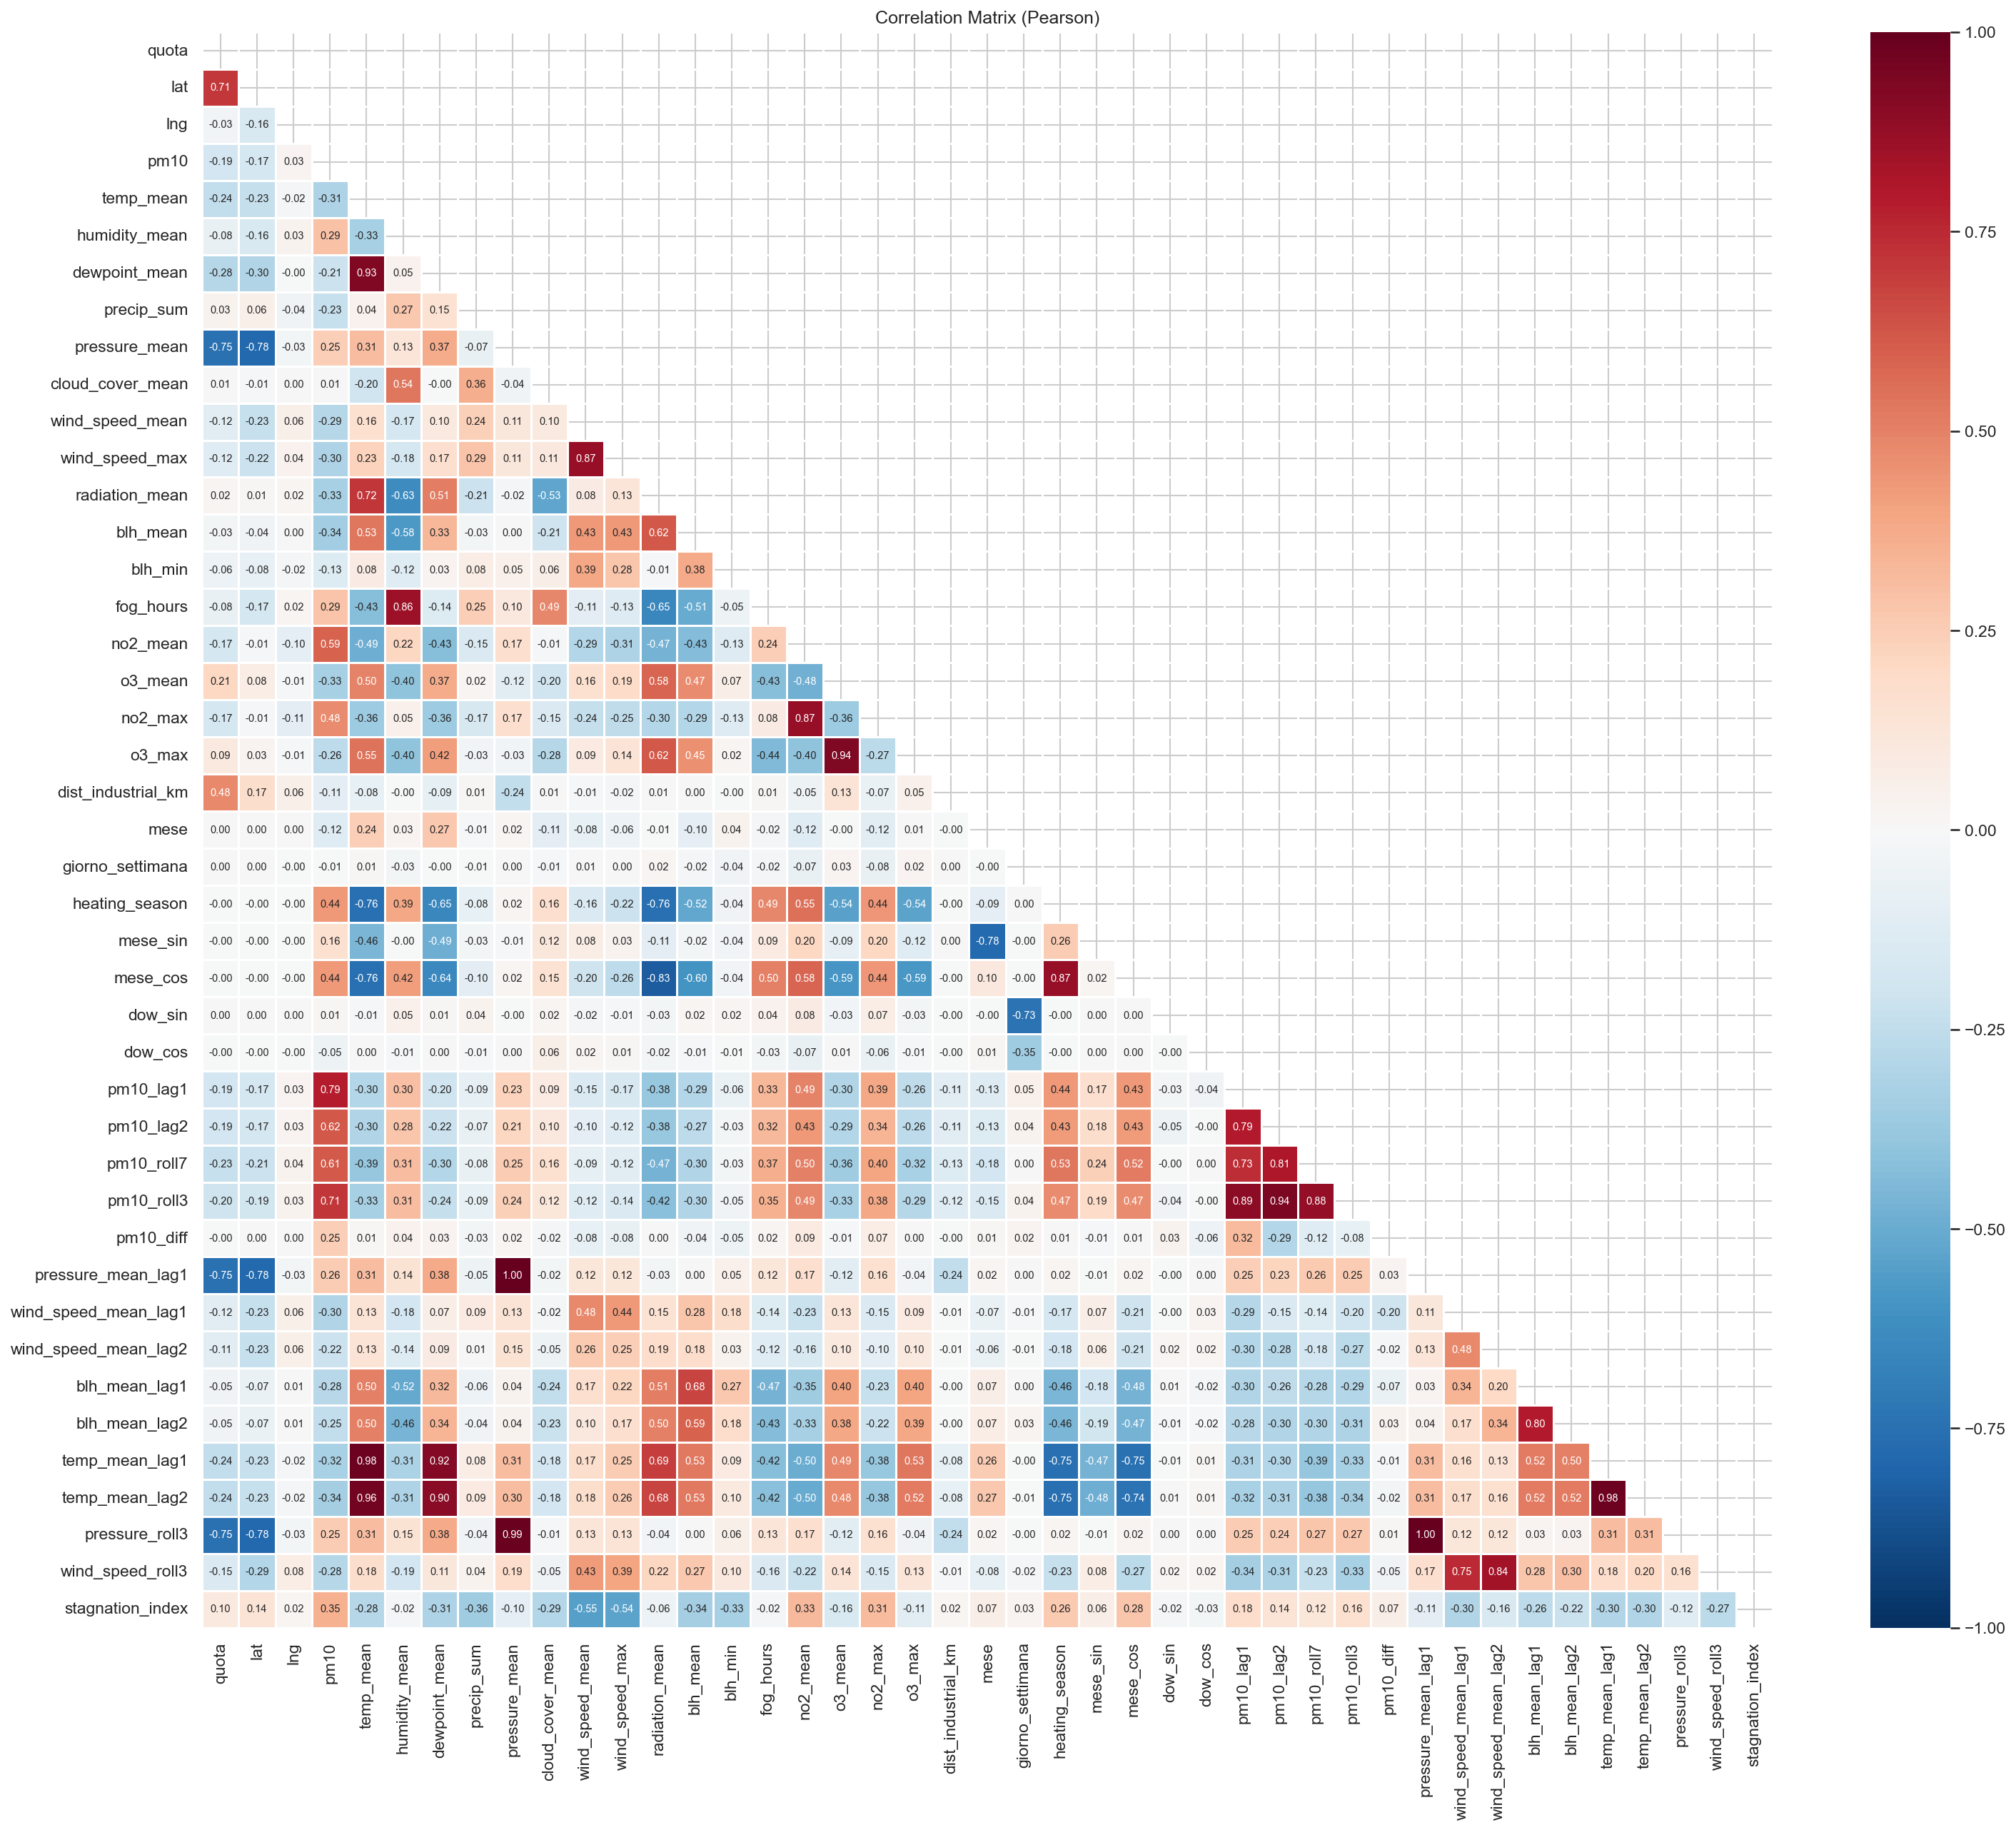

**05_pm10_timeseries.png**

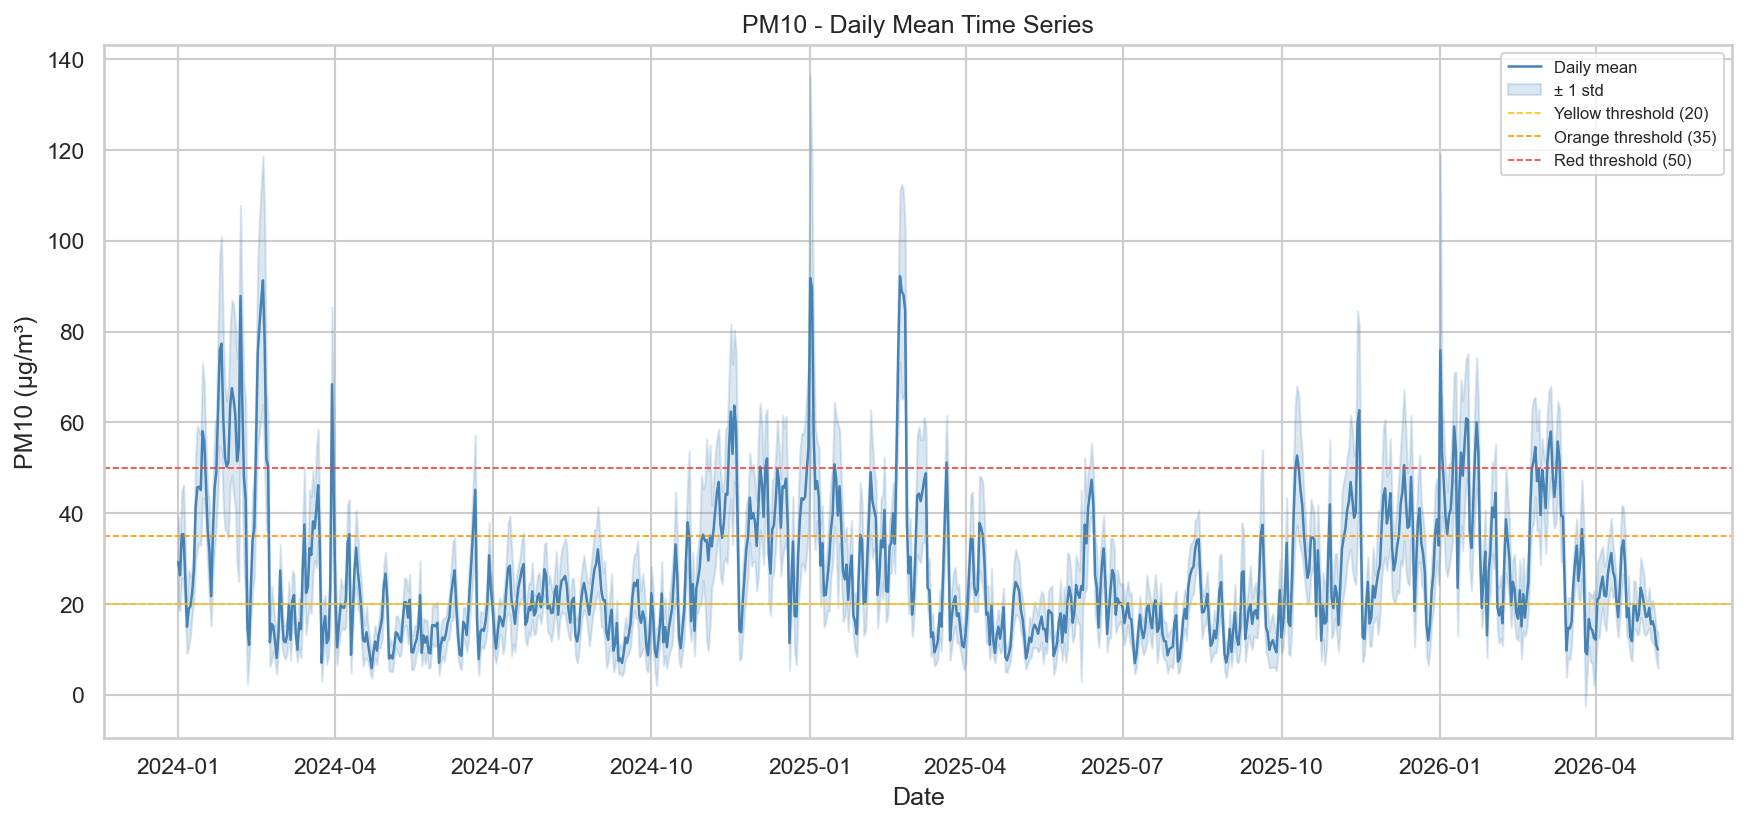

**06_pm10_by_season.png**

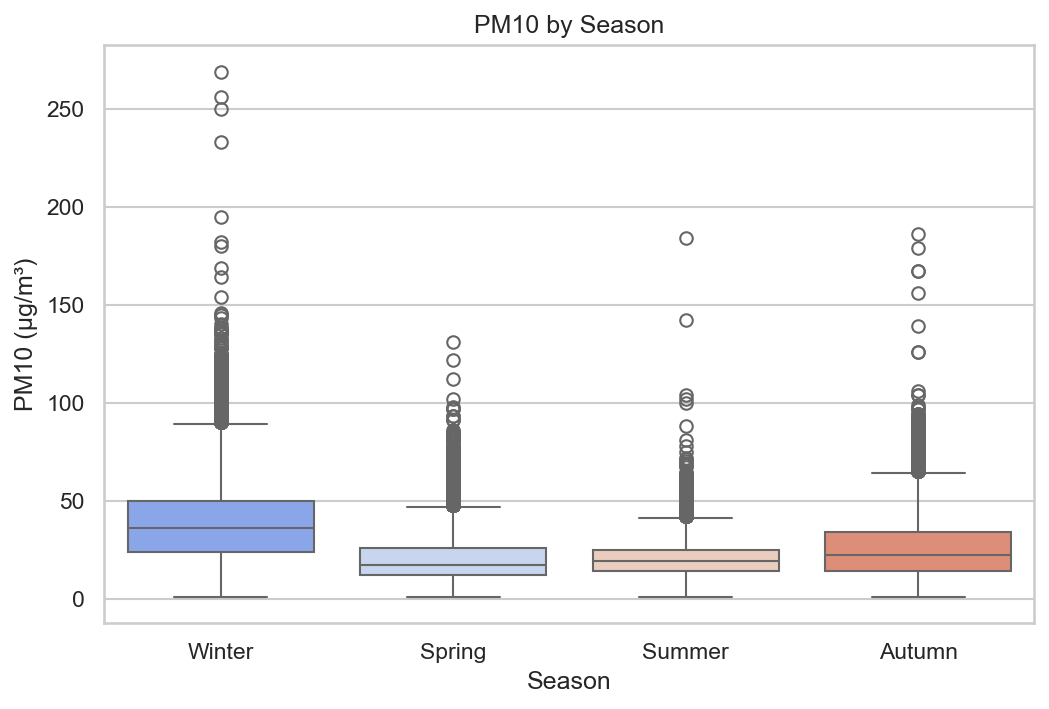

**07_pm10_by_weekday.png**

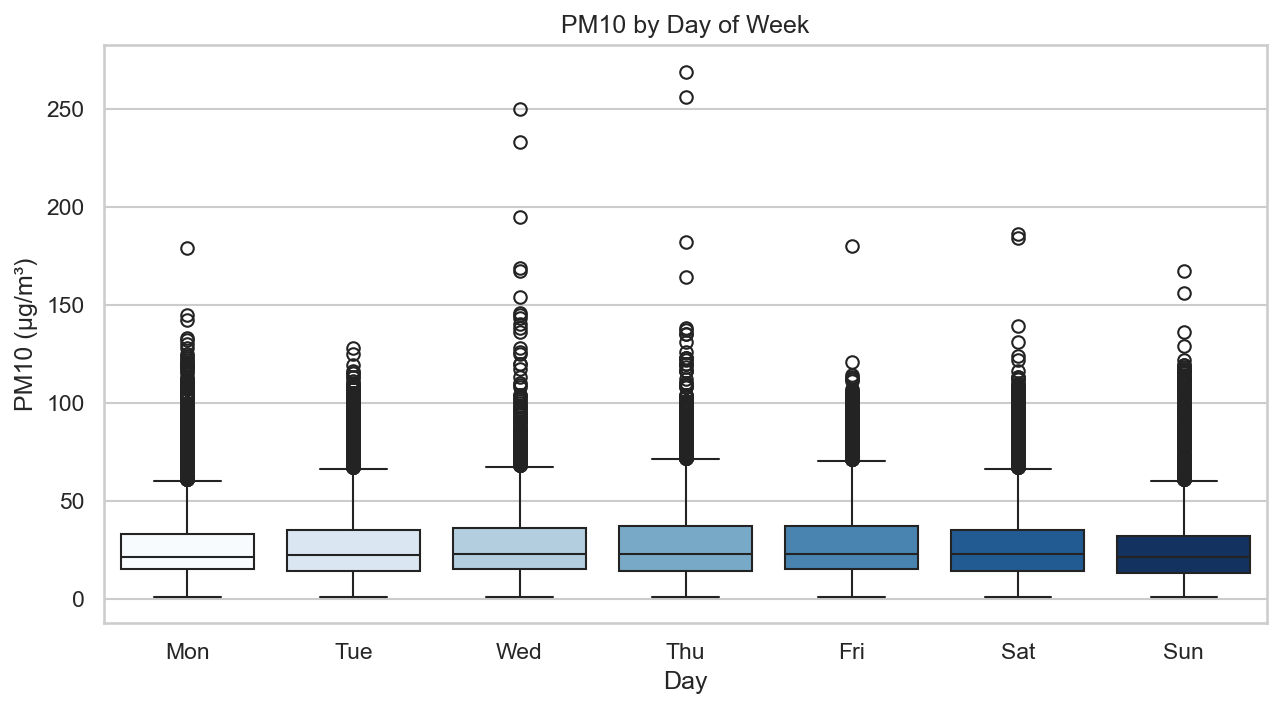

**08_pm10_monthly.png**

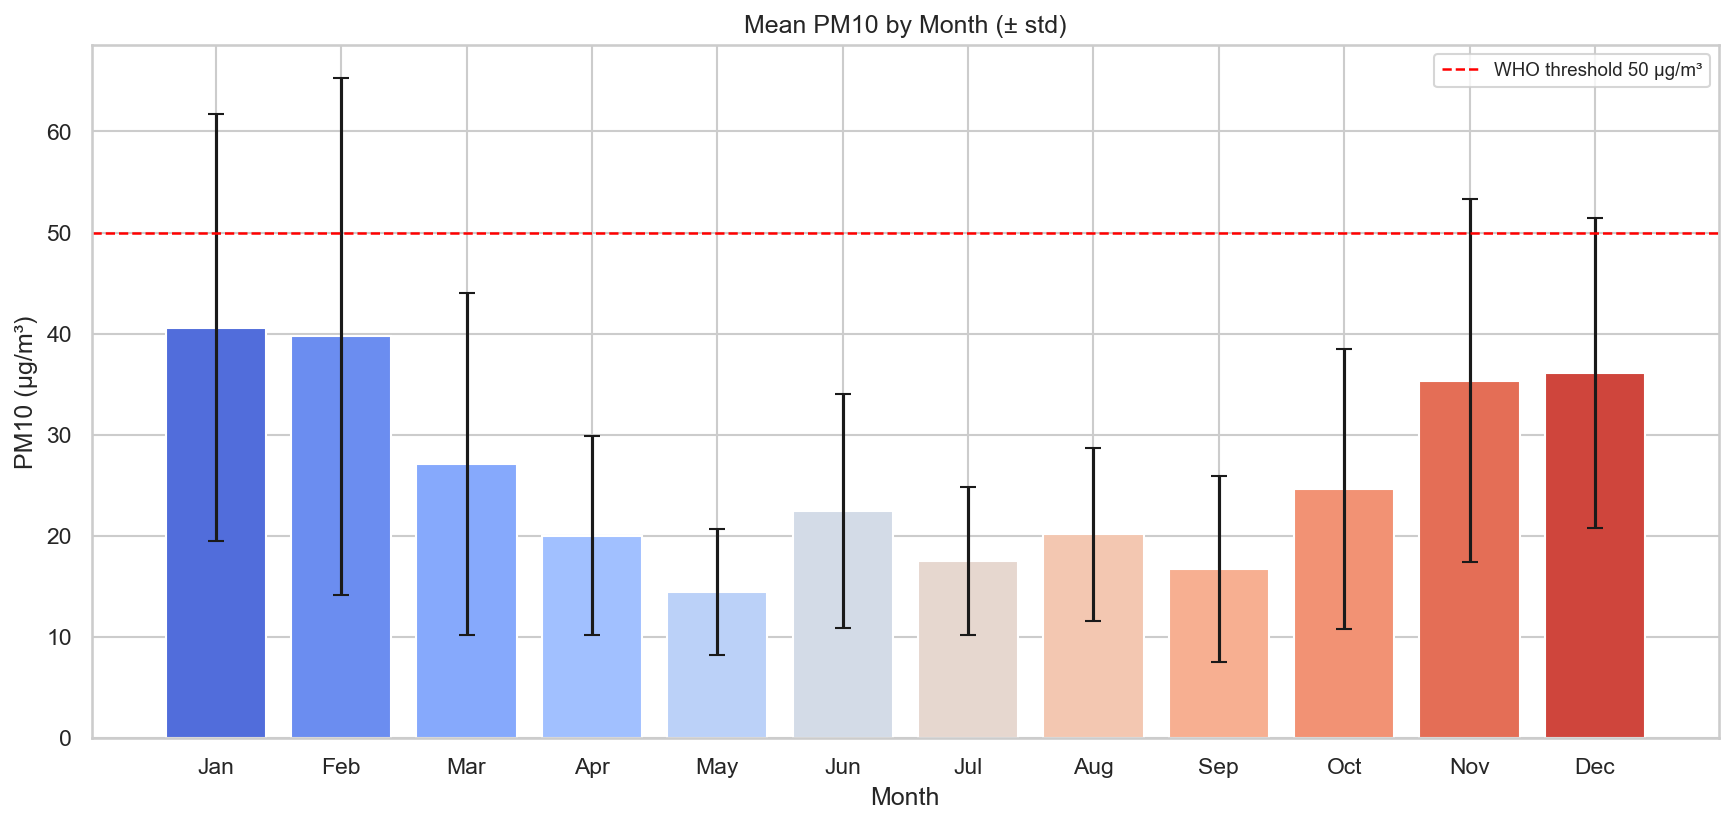

**09_pm10_by_provincia.png**

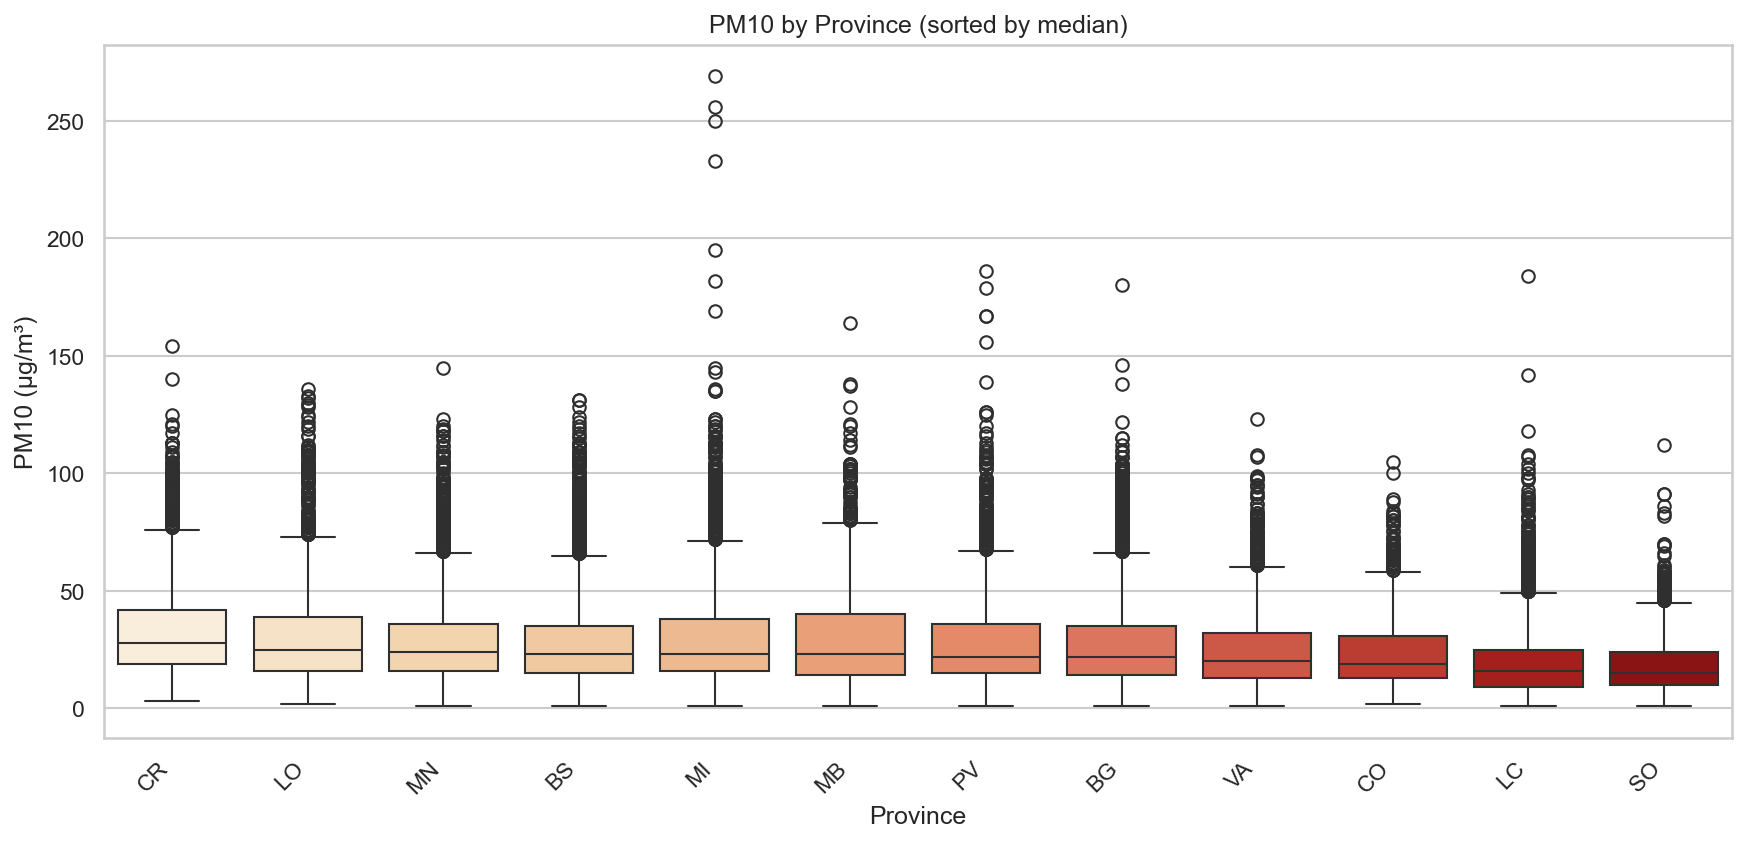

**10_weather_vs_pm10_scatter.png**

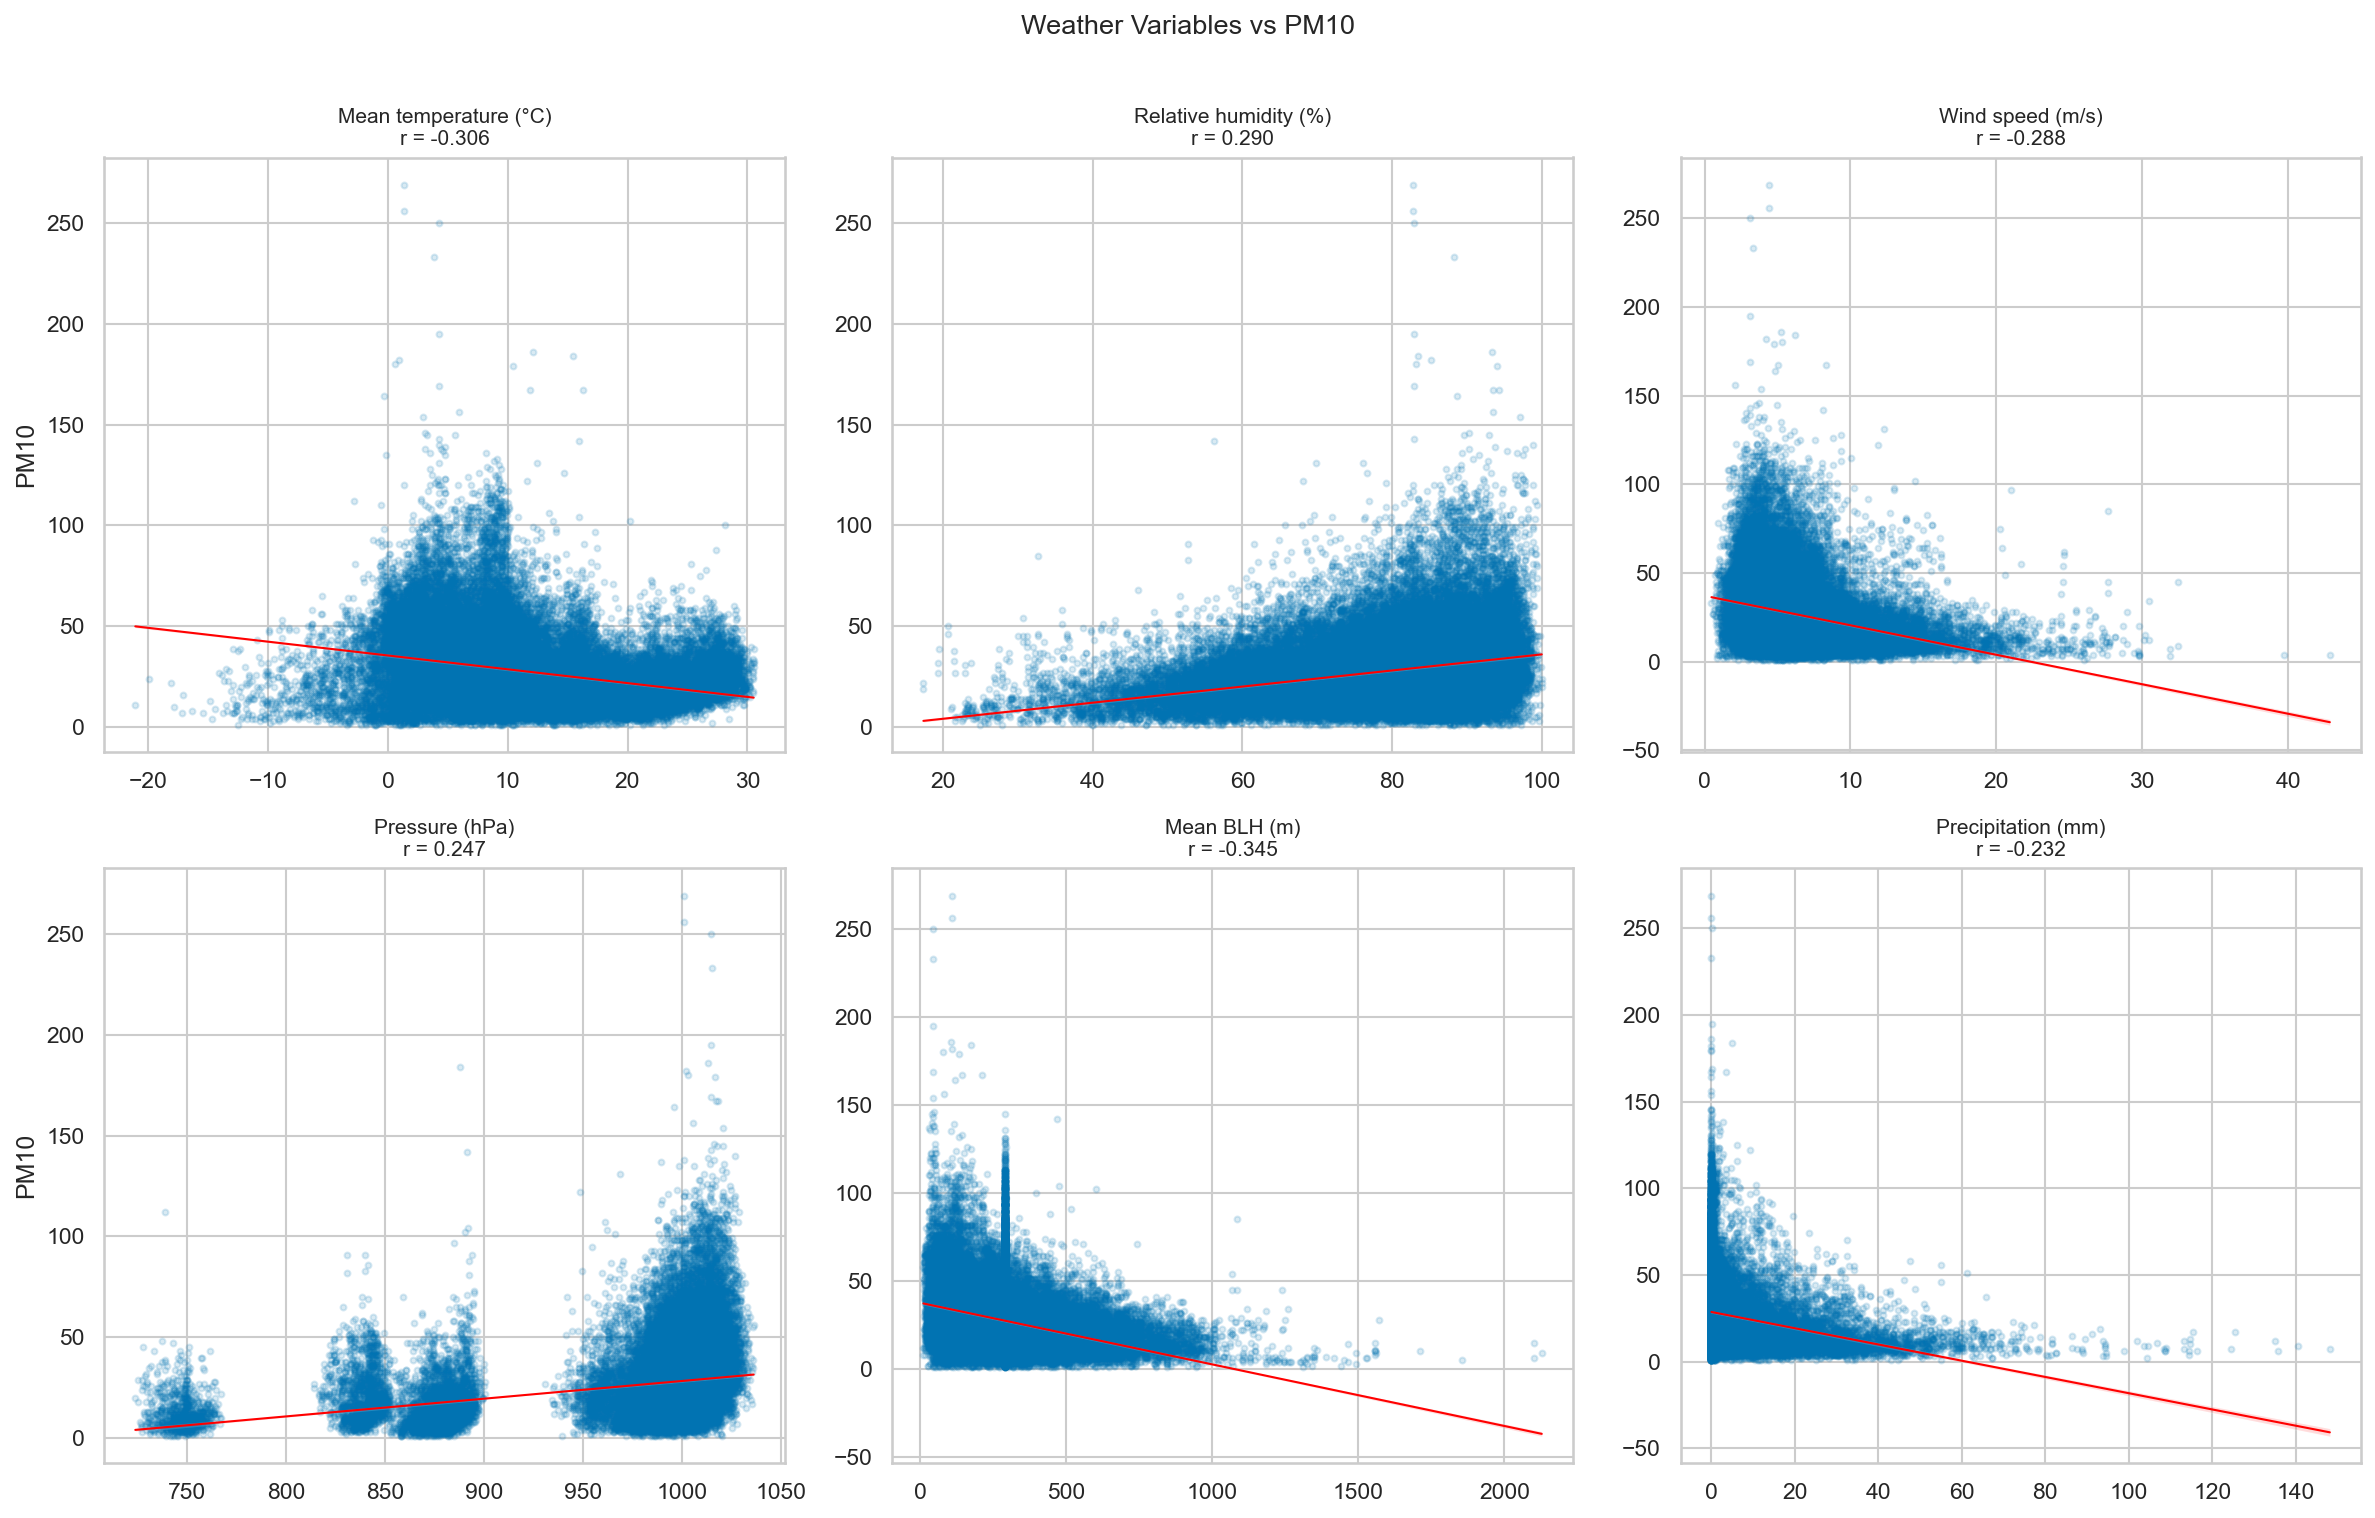

**11_stagnation_vs_pm10.png**

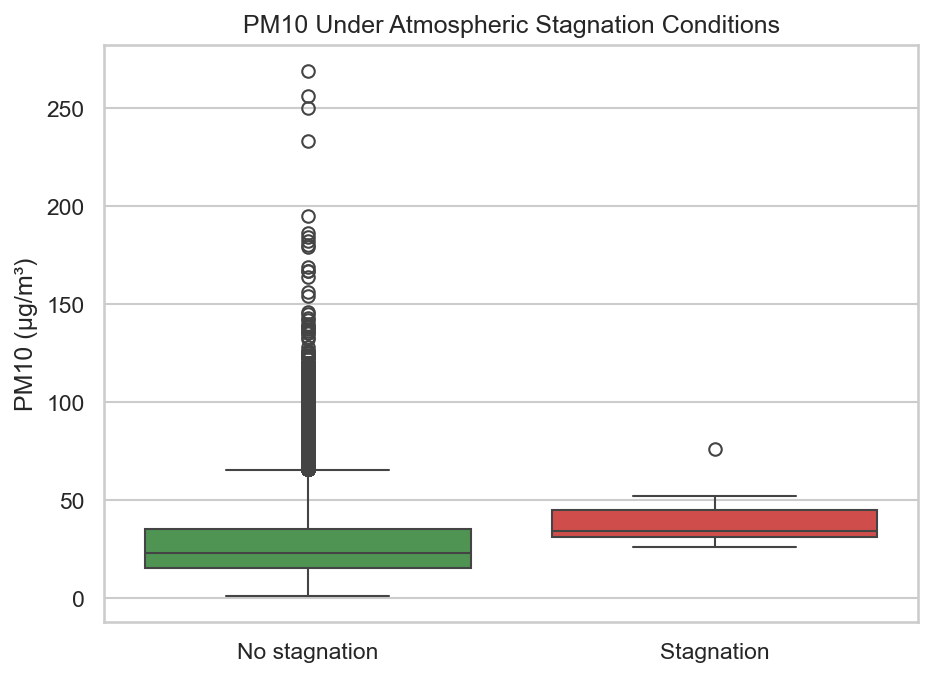

**12_industrial_vs_pm10.png**

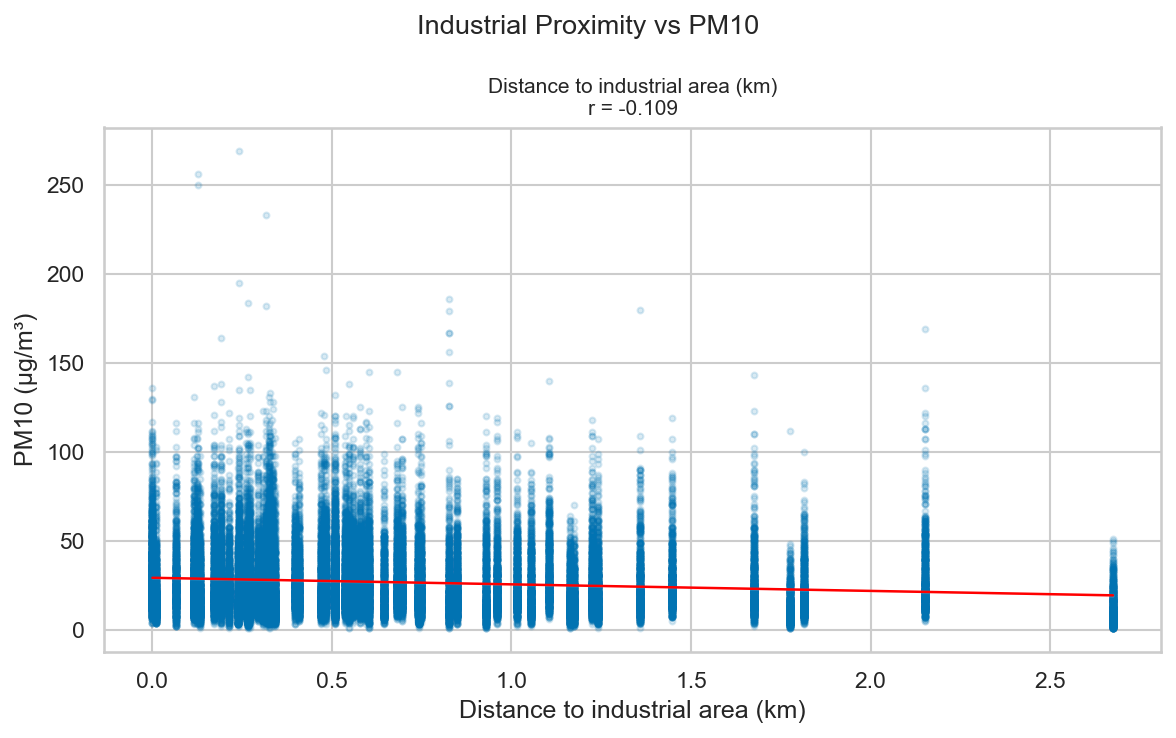

**13_no2_hourly_profile.png**

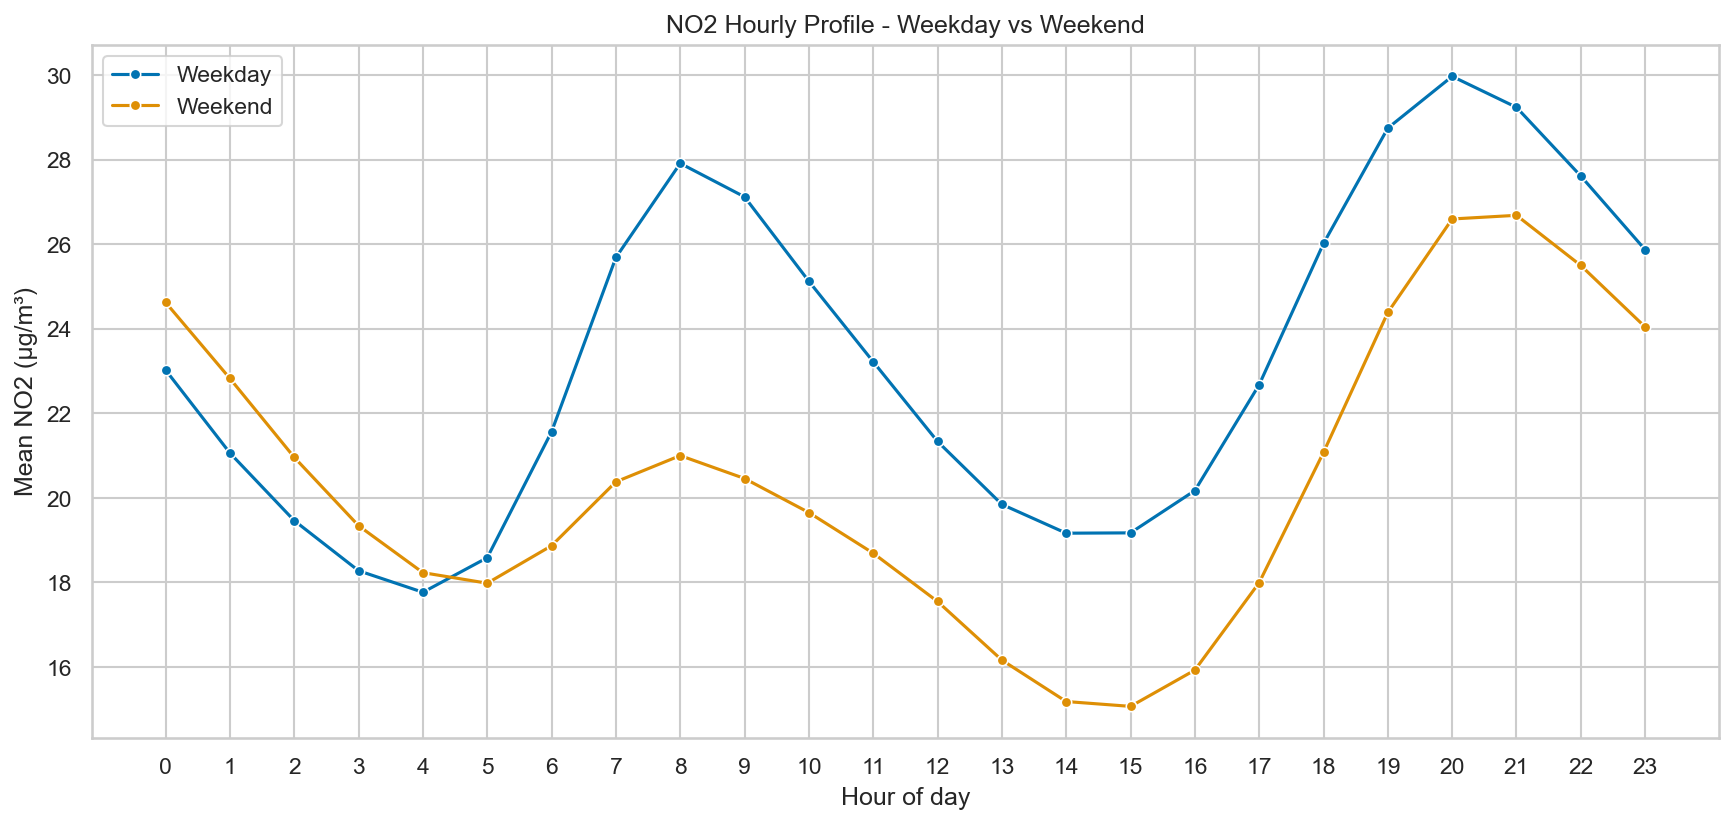

**14_rmt_eigenvalue_spectrum.png**

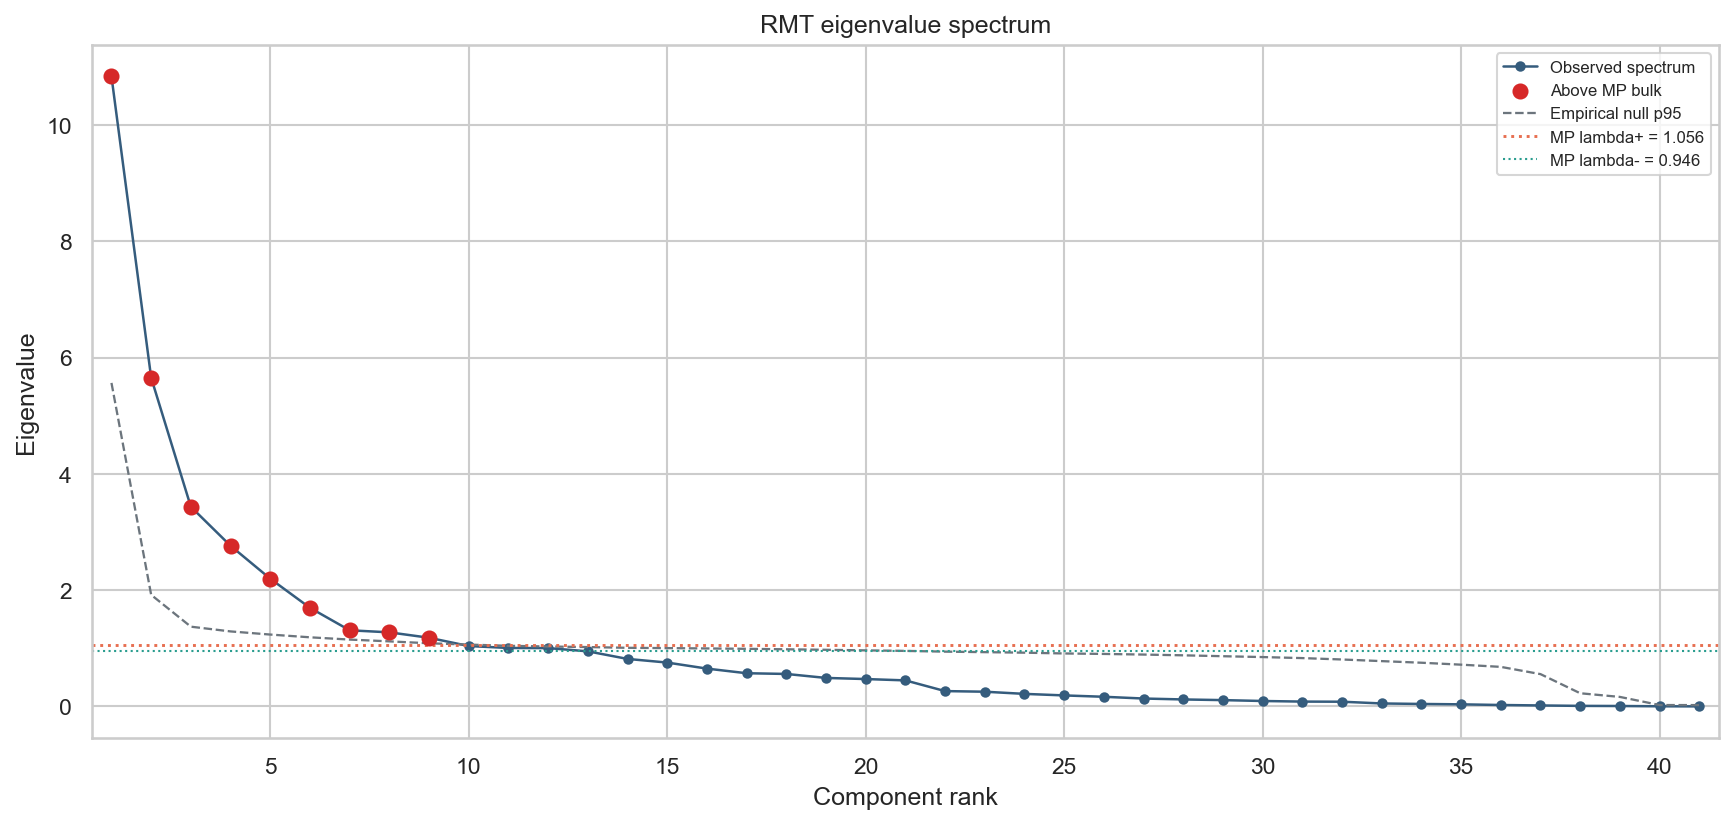

**15_rmt_top_eigenvector_loadings.png**

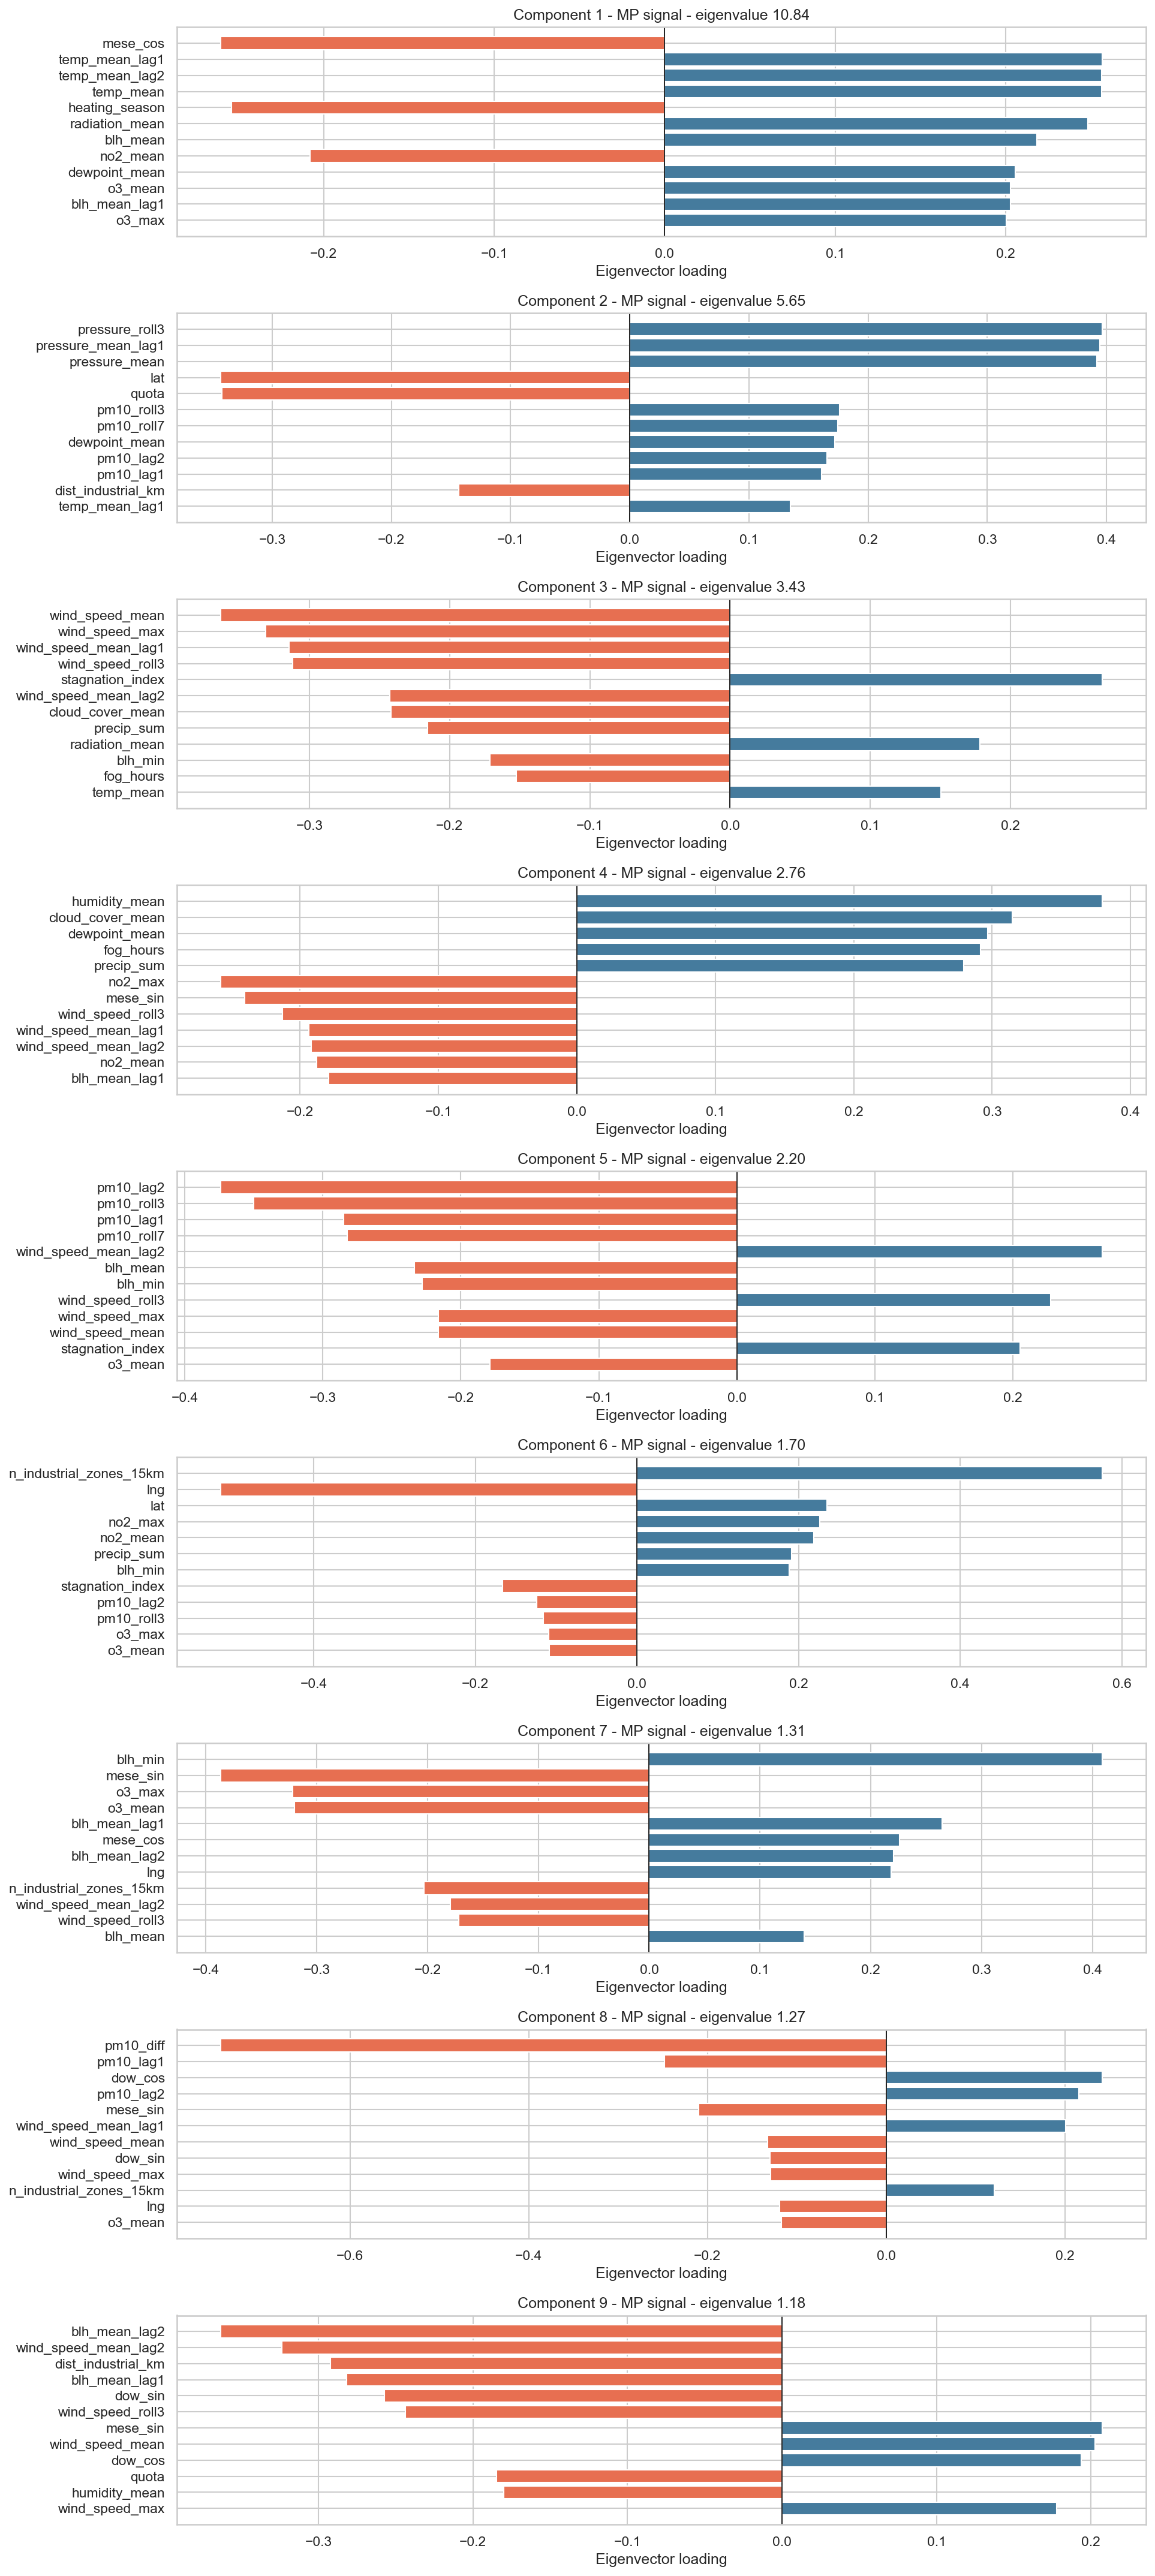

**16_rmt_empirical_null_comparison.png**

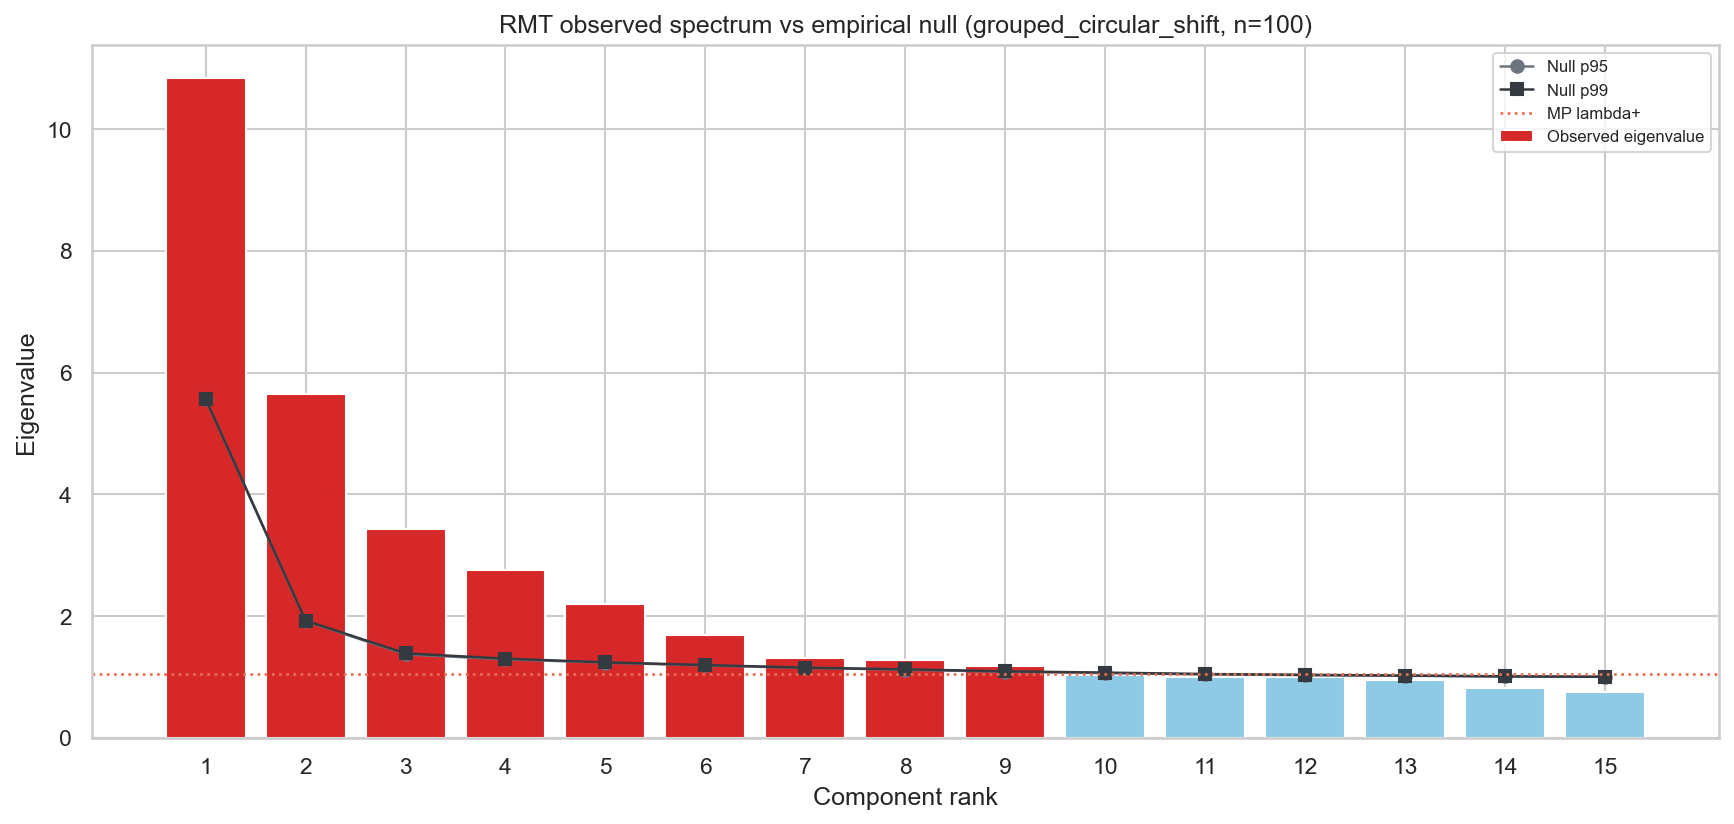

In [6]:
eda_plots = sorted(EDA_PLOTS_DIR.glob("*.png"))  # 01-13: core EDA, 14-16: RMT diagnostic
assert len(eda_plots) == 16, f"Expected 16 EDA plots, found {len(eda_plots)}"
for plot_path in eda_plots:
    show_plot(plot_path)

## Section 5 — PM10 Regression

**Step 4** compares three models (sklearn pipelines with shared preprocessing, tuning via
day-grouped 5-fold `TimeSeriesSplit`, log-transformed target) on a **temporal split**:
train 2024-01-01 → 2025-08-22, test 2025-08-23 → 2026-05-07 (16,260 samples, 67 stations).

In [7]:
with open(REG_METRICS, encoding="utf-8") as f:
    reg = json.load(f)

reg_table = pd.DataFrame([
    {
        "model": name,
        "R2": m["r2"],
        "RMSE (ug/m3)": m["rmse"],
        "MAE (ug/m3)": m["mae"],
        "RMSE rosso class": m["rmse_per_fascia"]["rosso"],
    }
    for name, m in reg["models"].items()
]).sort_values("R2", ascending=False).reset_index(drop=True)

print(f"Best model: {reg['best_model']}  (test: {reg['test_date_range'][0][:10]} -> {reg['test_date_range'][1][:10]}, n={reg['n_test_samples']:,})")
reg_table

Best model: xgboost  (test: 2025-08-23 -> 2026-05-07, n=16,260)


,model,R2,RMSE (ug/m3),MAE (ug/m3),RMSE rosso class
0,xgboost,0.696,9.235,6.257,17.828
1,random_forest,0.686,9.384,6.390,18.149
2,elasticnet,0.018,16.596,7.923,41.005


**elasticnet_diagnostics.png**

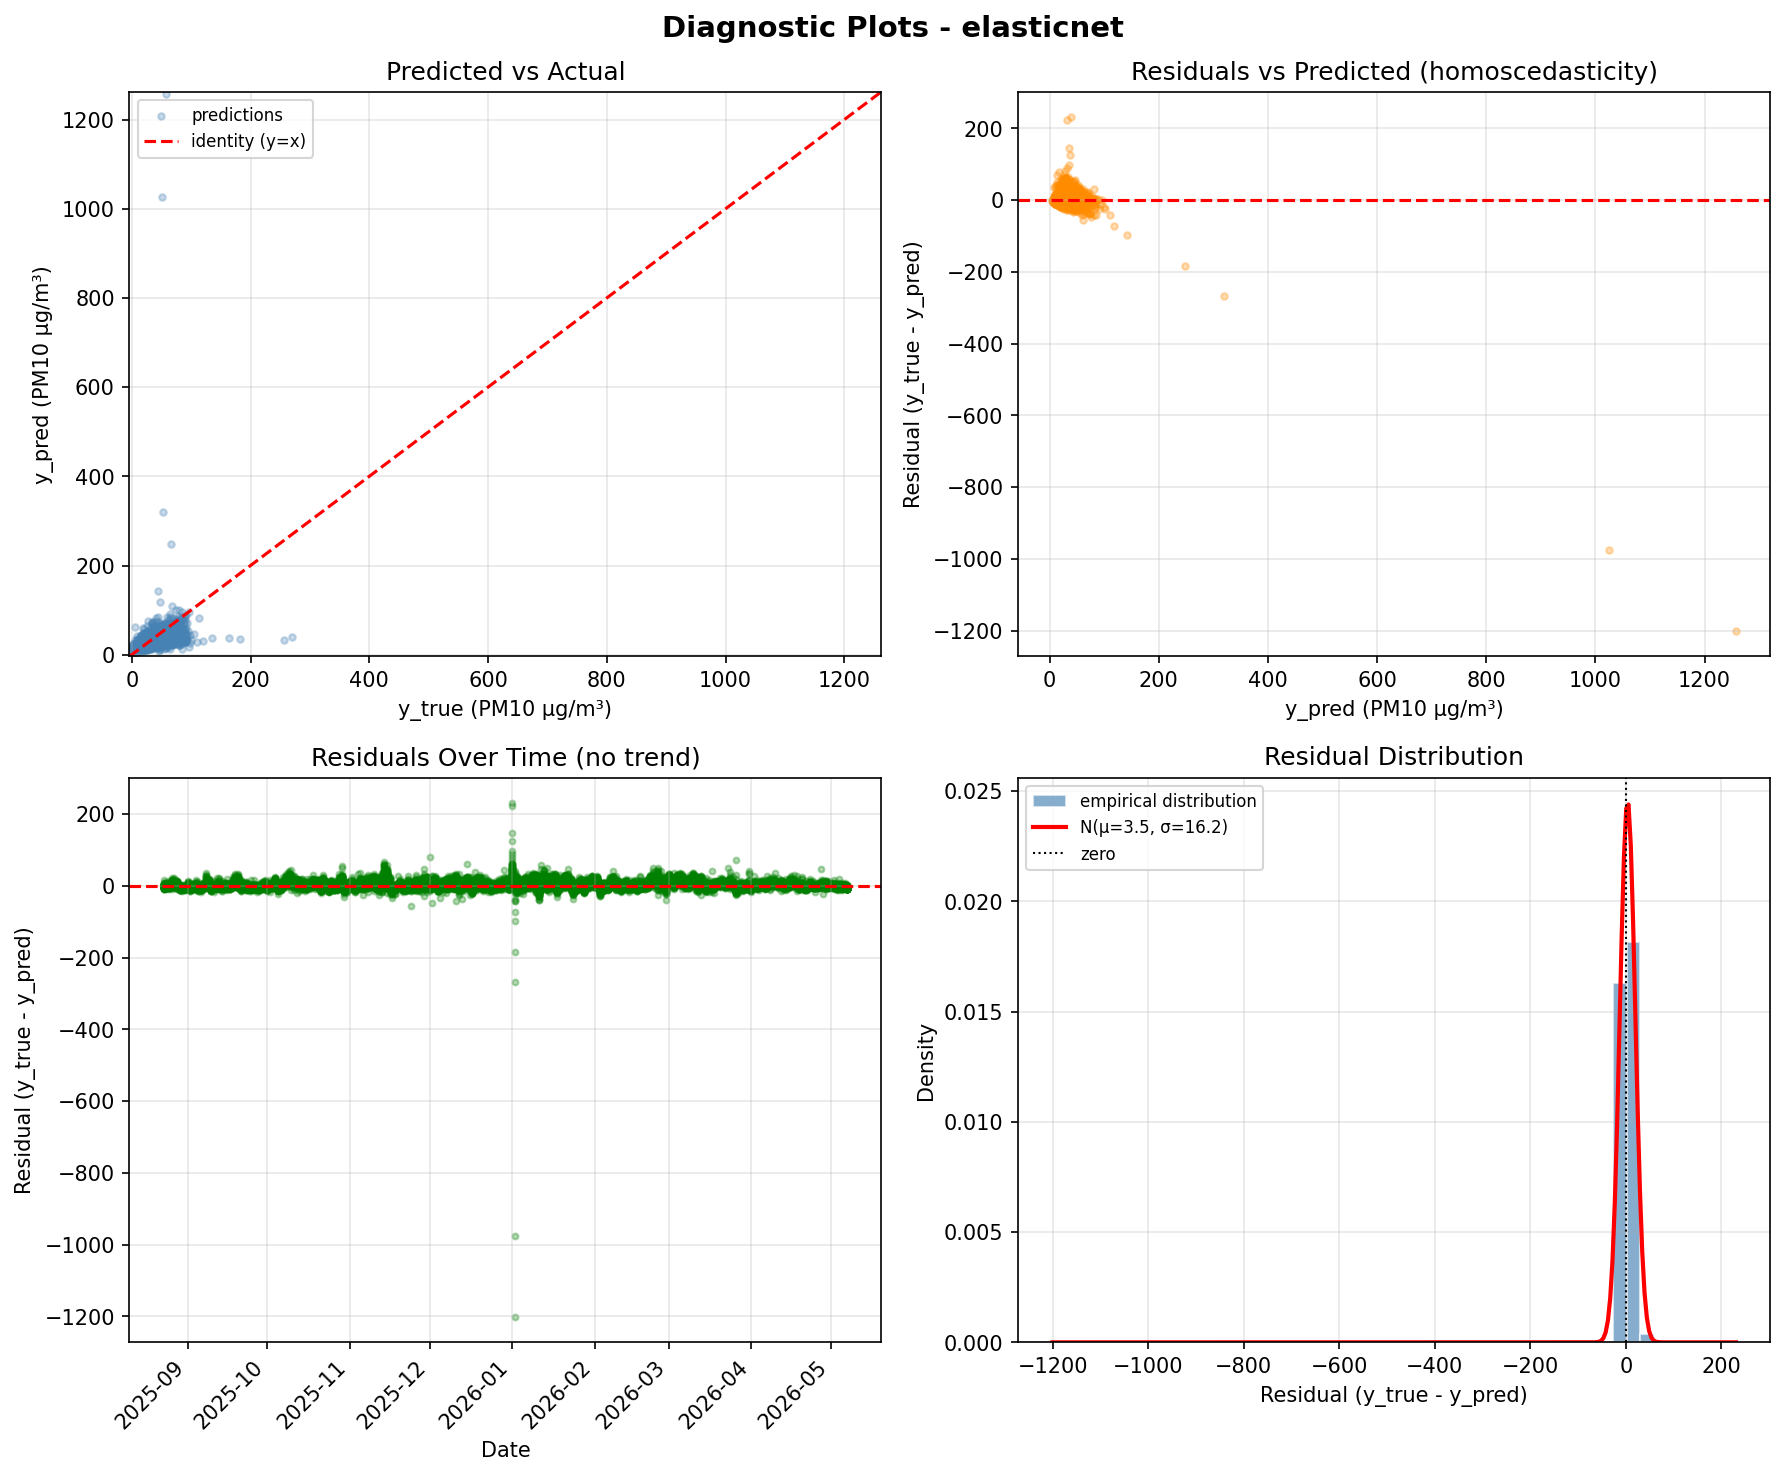

**random_forest_diagnostics.png**

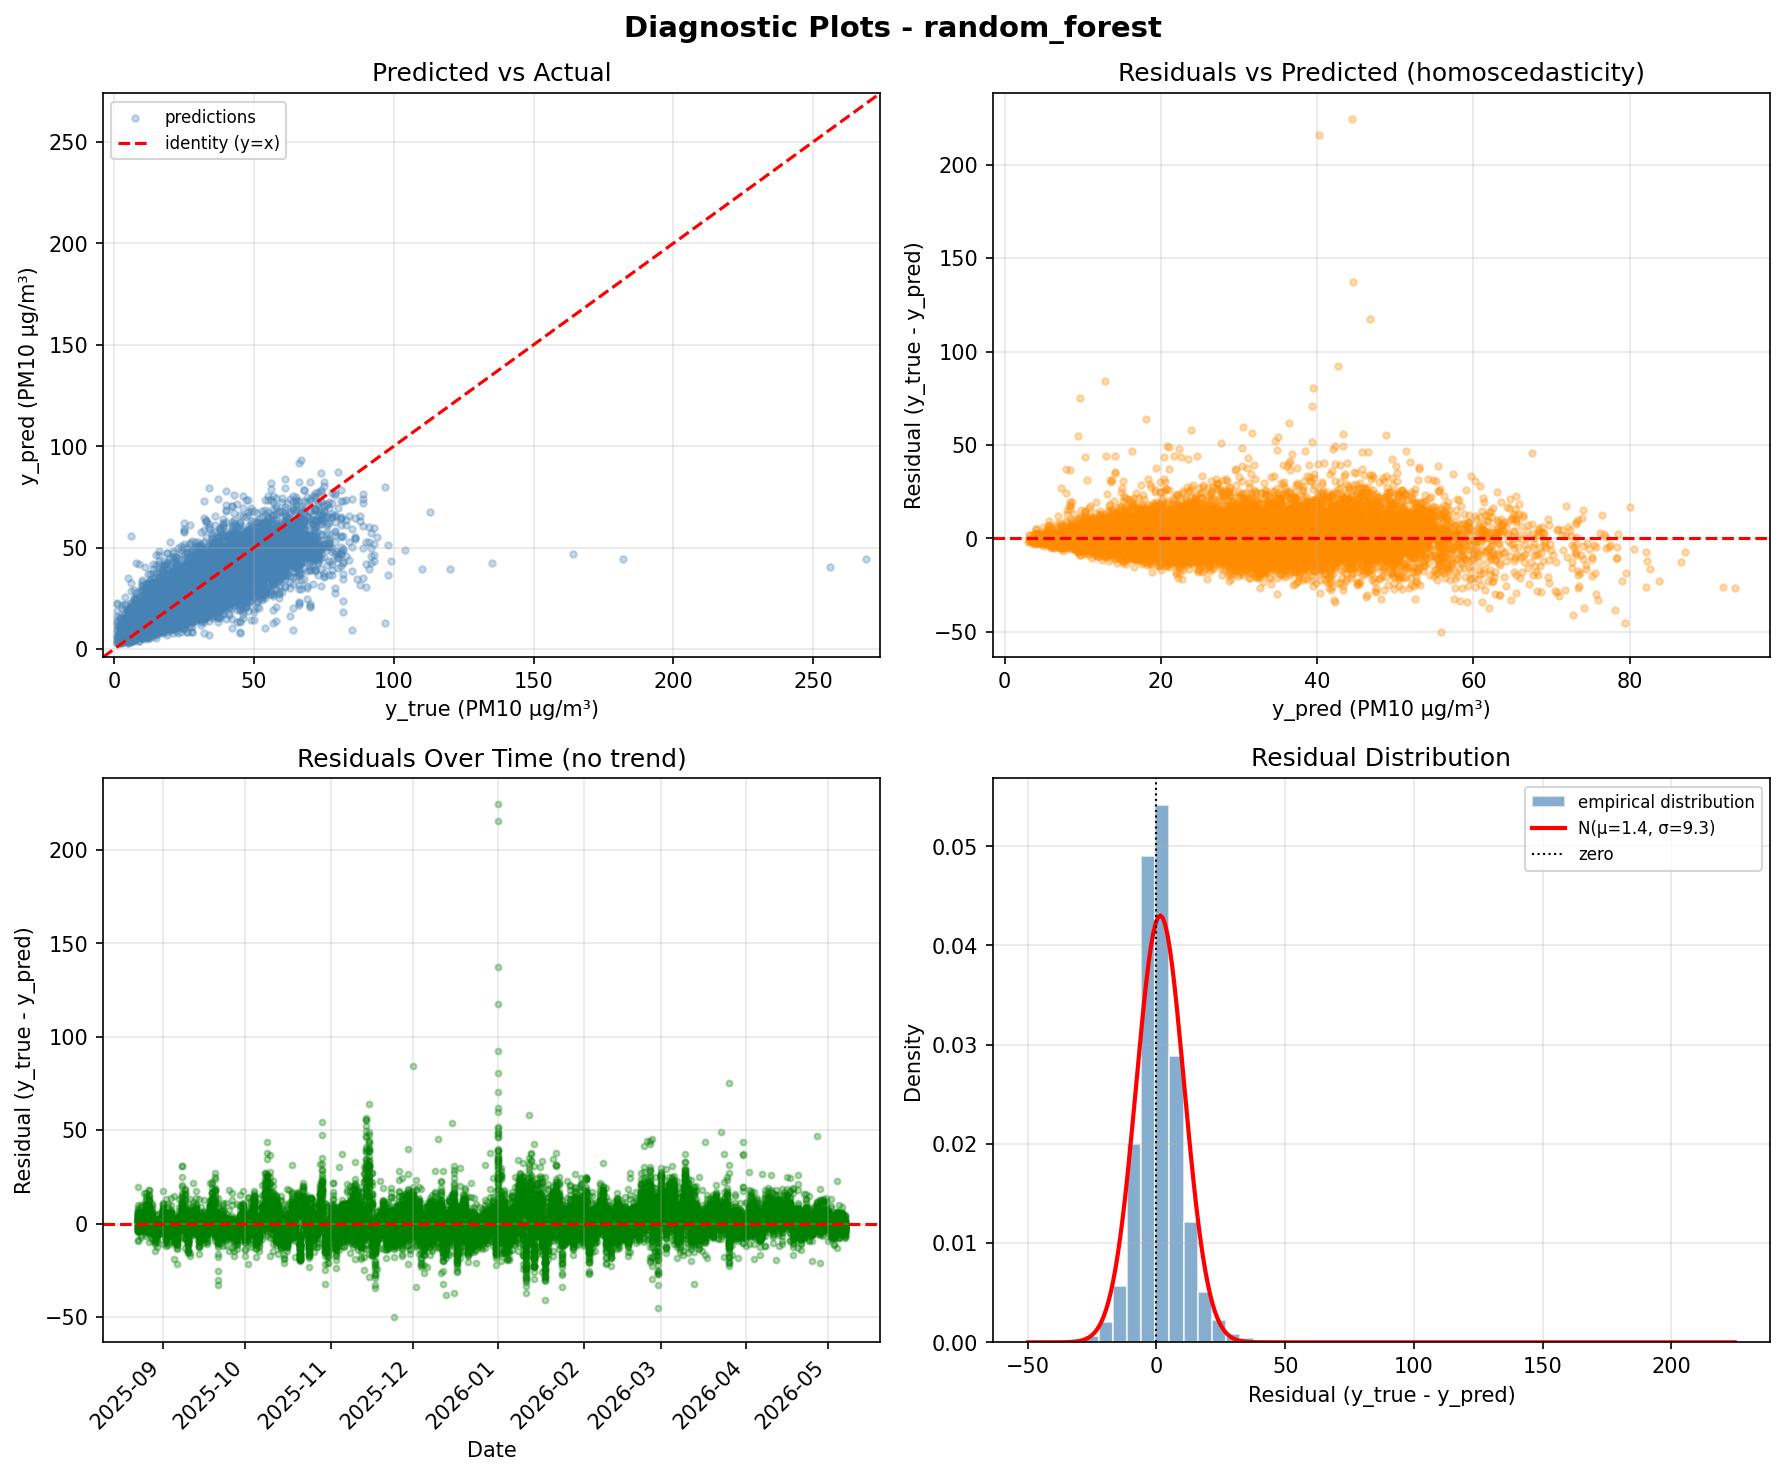

**xgboost_diagnostics.png**

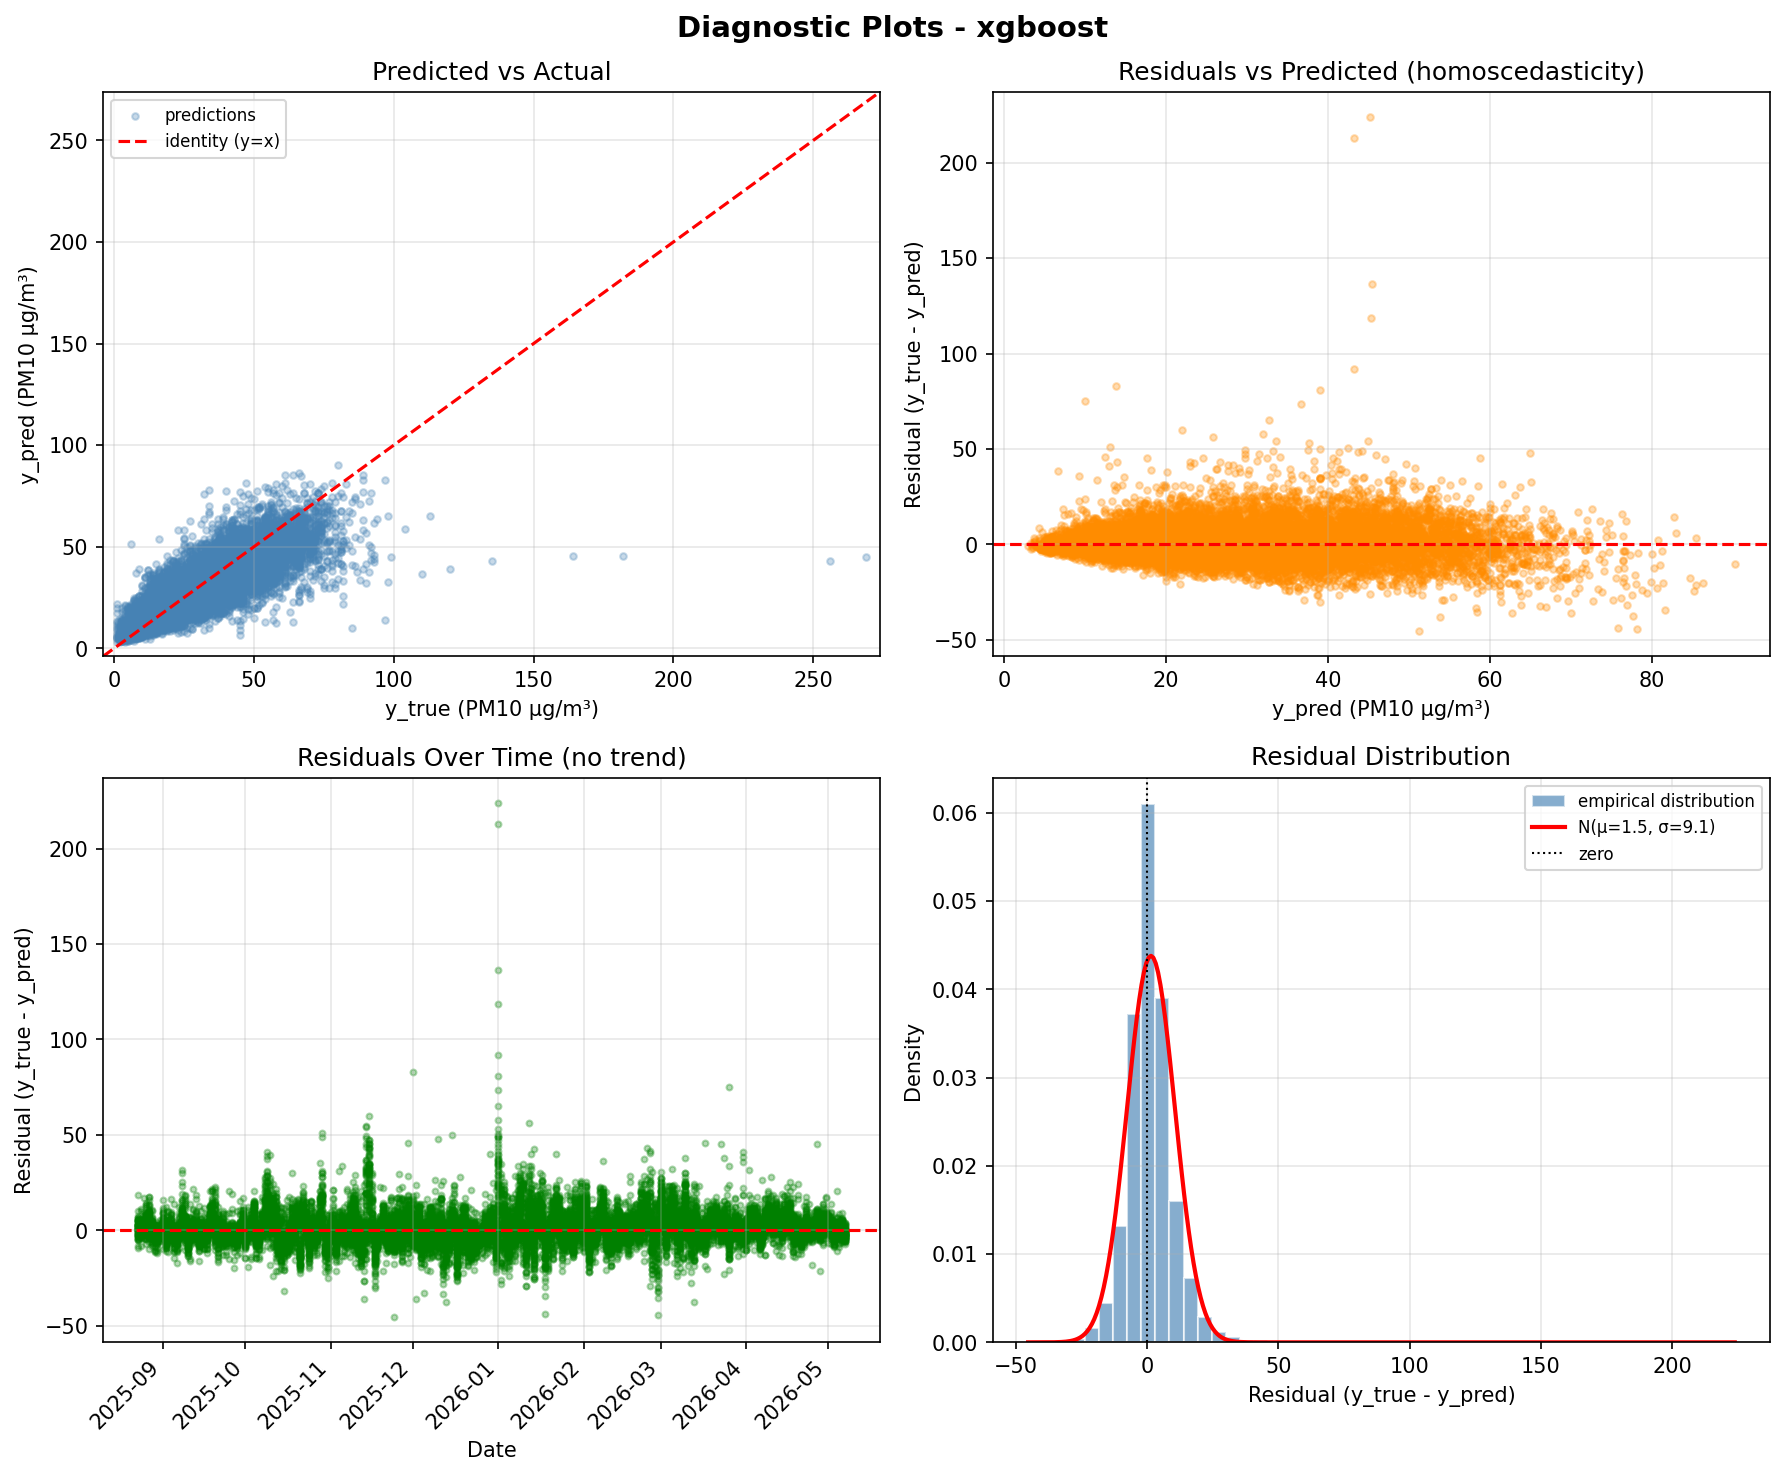

In [8]:
# Per-model diagnostics (predicted vs actual, residuals) on the test set
for name in ("elasticnet", "random_forest", "xgboost"):
    show_plot(REG_PLOTS_DIR / f"{name}_diagnostics.png")

**elasticnet_native_importance.png**

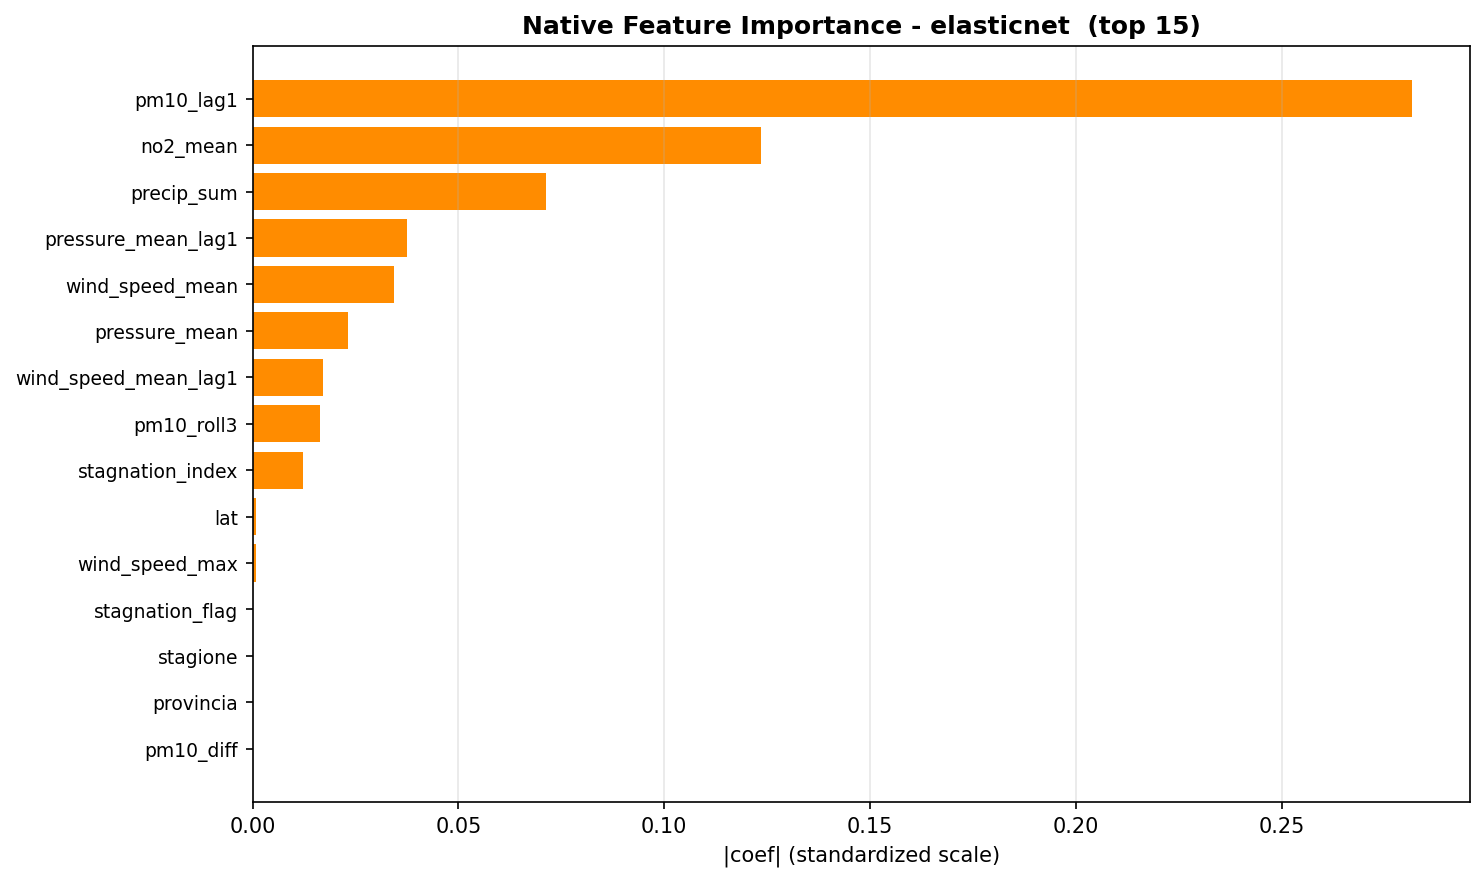

**random_forest_permutation_importance.png**

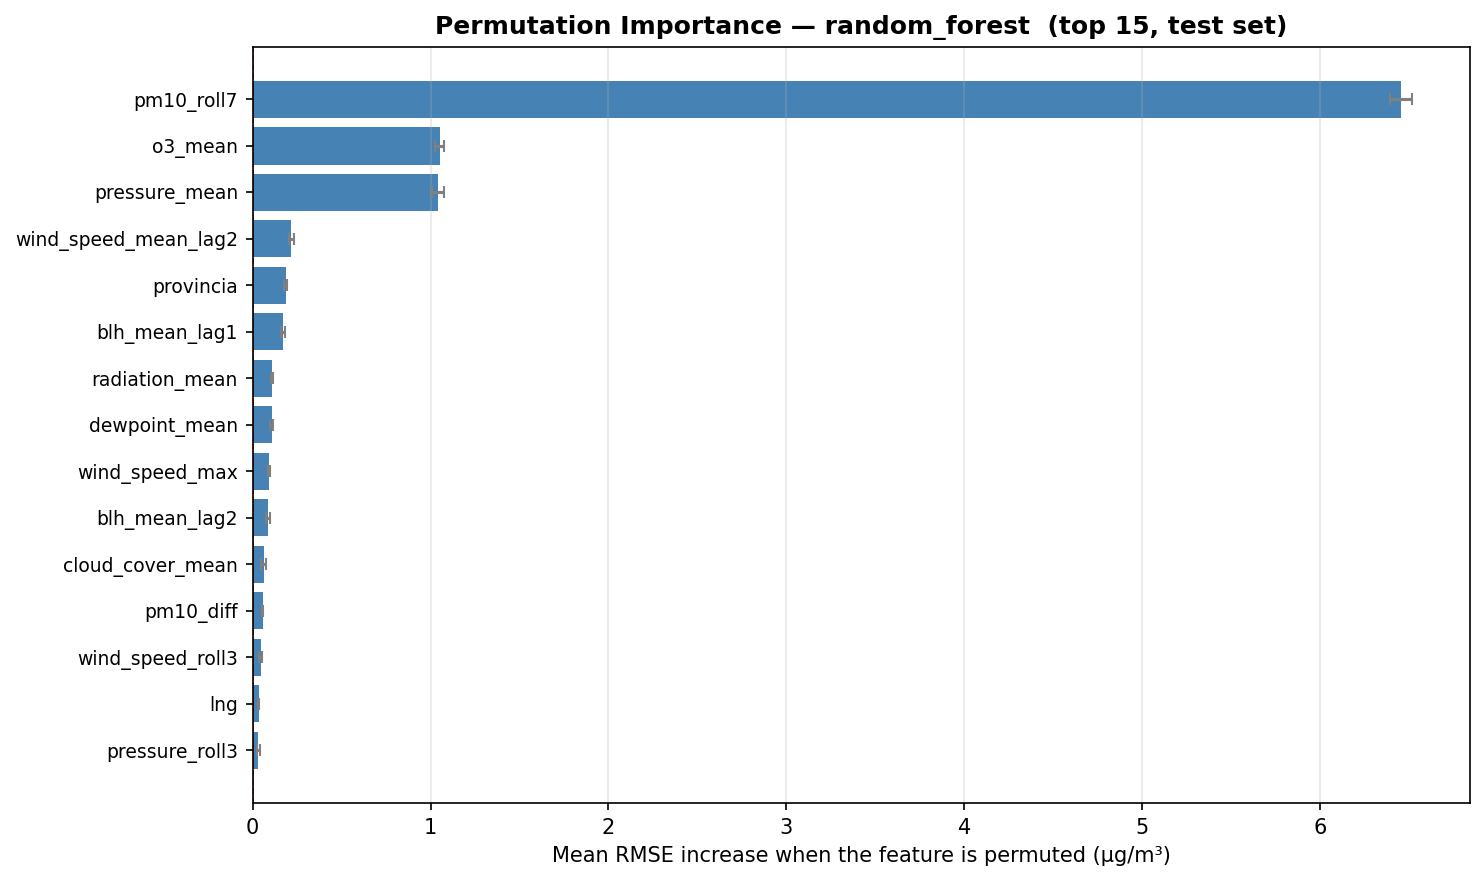

**xgboost_permutation_importance.png**

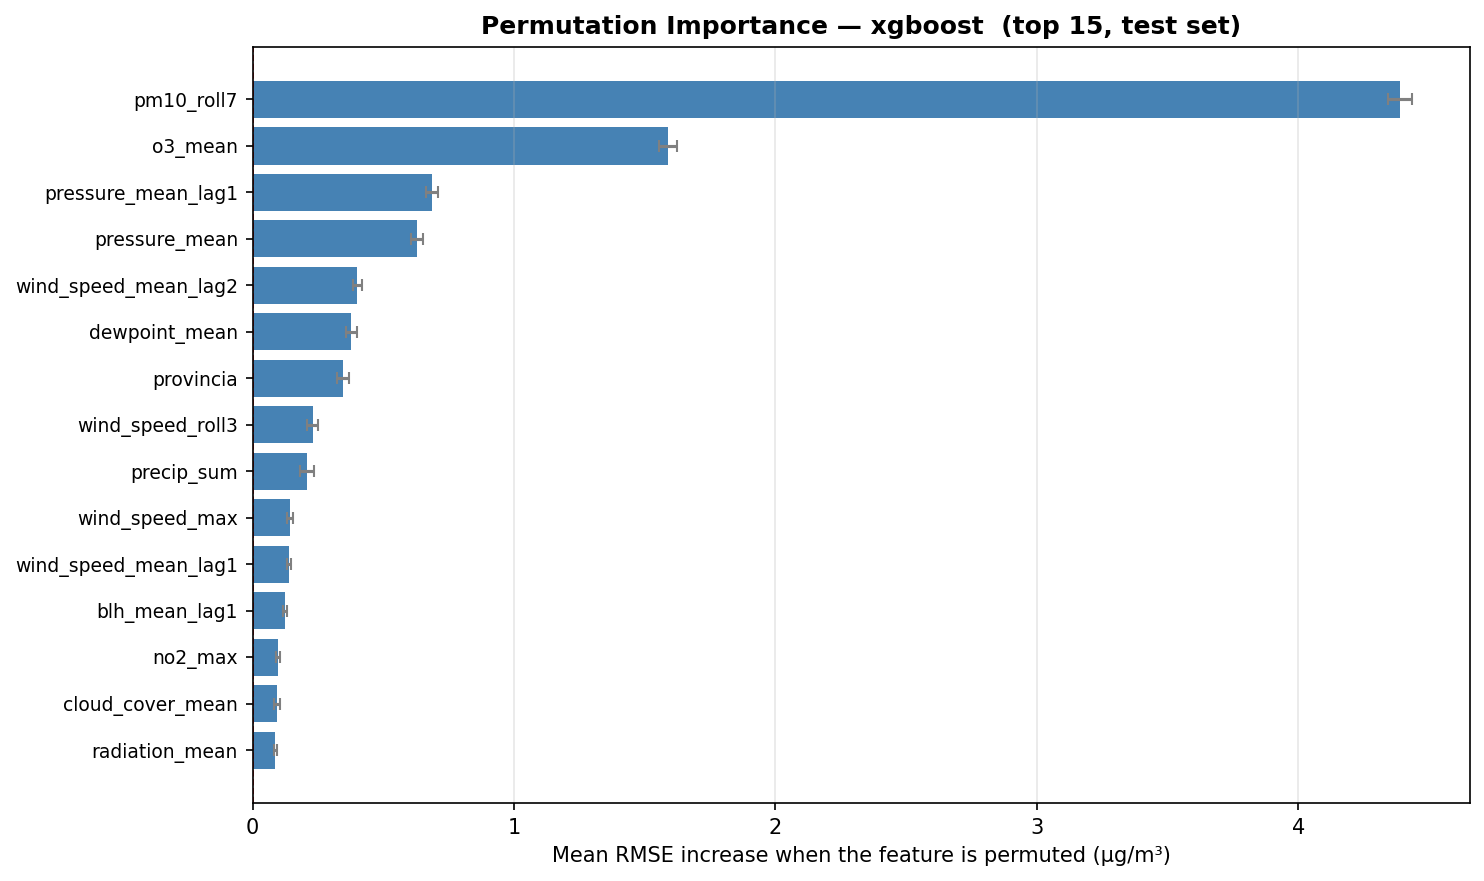

In [9]:
# Feature importance: native coefficients for ElasticNet, permutation importance for the tree models
for importance_plot in (
    "elasticnet_native_importance.png",
    "random_forest_permutation_importance.png",
    "xgboost_permutation_importance.png",
):
    show_plot(REG_PLOTS_DIR / importance_plot)

## Section 6 — Alert Classification

**Step 5** tackles the 4-class problem (`verde/giallo/arancio/rosso`) with 7 strategies:
3 base classifiers, the discretised regressor, an ordinal classifier (Frank & Hall),
calibrated XGBoost (isotonic), and a **hybrid strategy** combining the regressor with the
calibrated classifier (the classifier may escalate the class only near the thresholds, when
sufficiently confident).

Production constraints: `severe_error_rate ≤ 2.5%` **and** `recall_rosso ≥ 0.65` — only the
hybrid satisfies both.

In [10]:
with open(CLS_METRICS, encoding="utf-8") as f:
    cls = json.load(f)
with open(CLS_SELECTION, encoding="utf-8") as f:
    selection = json.load(f)

cls_table = pd.DataFrame([
    {
        "strategy": name,
        "F1-macro": m["f1_macro"],
        "accuracy": m["accuracy"],
        "recall_rosso": m["recall_rosso"],
        "severe_error_rate": m["severe_error_rate"],
    }
    for name, m in cls["models"].items()
]).sort_values("F1-macro", ascending=False).reset_index(drop=True)

selected = selection["selected_strategy"]["strategy_name"]
print(f"Selected production-ready strategy: {selected}")
print(f"Reason: {selection['selection_reason']}")
cls_table

Selected production-ready strategy: hybrid_xgboost_reg_xgboost_cls
Reason: Only strategy, or best by f1_macro within +/-0.005, that satisfies severe_error_rate <= 2.5% and recall_rosso >= 0.65.


,strategy,F1-macro,accuracy,recall_rosso,severe_error_rate
0,xgboost,0.639,0.650,0.618,0.019
1,hybrid_xgboost_reg_xgboost_cls,0.636,0.660,0.680,0.023
2,random_forest,0.634,0.648,0.576,0.021
3,regression_to_class_xgboost,0.625,0.654,0.464,0.019
4,xgboost_ordinal,0.619,0.641,0.803,0.030
5,logistic_regression,0.616,0.622,0.657,0.028
6,classifier_xgboost_calibrated,0.603,0.639,0.667,0.030


**logistic_regression_confusion_matrix.png**

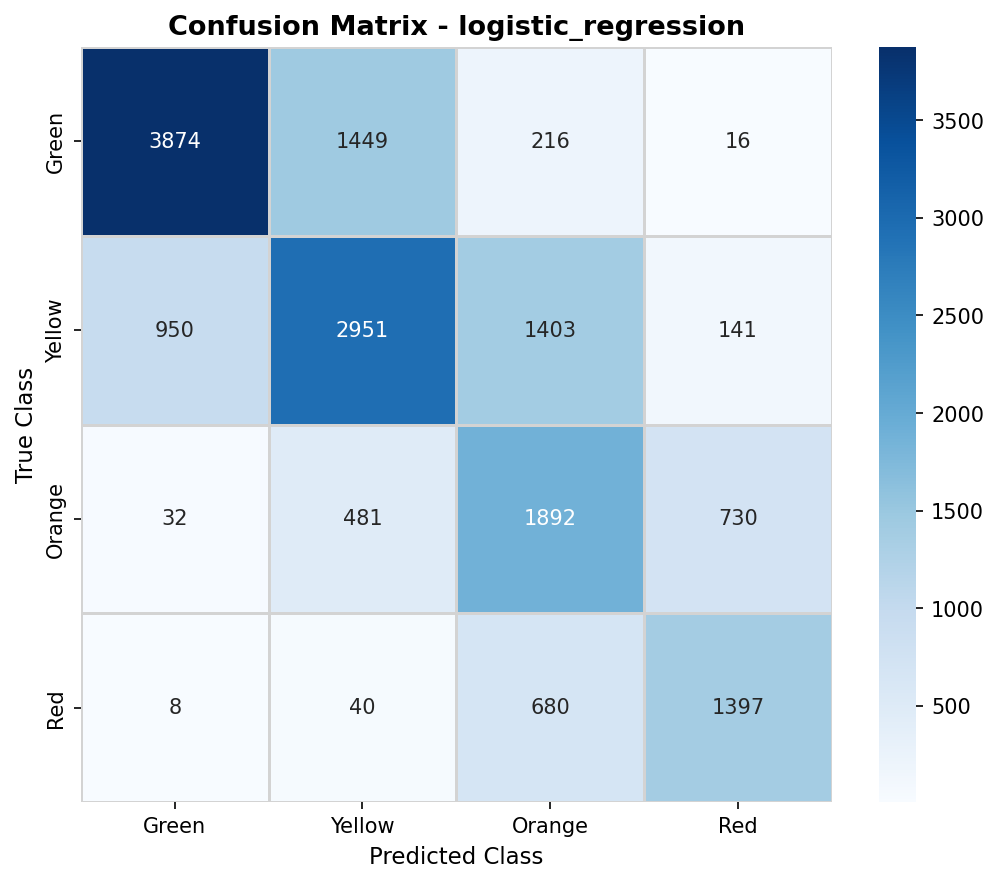

**random_forest_confusion_matrix.png**

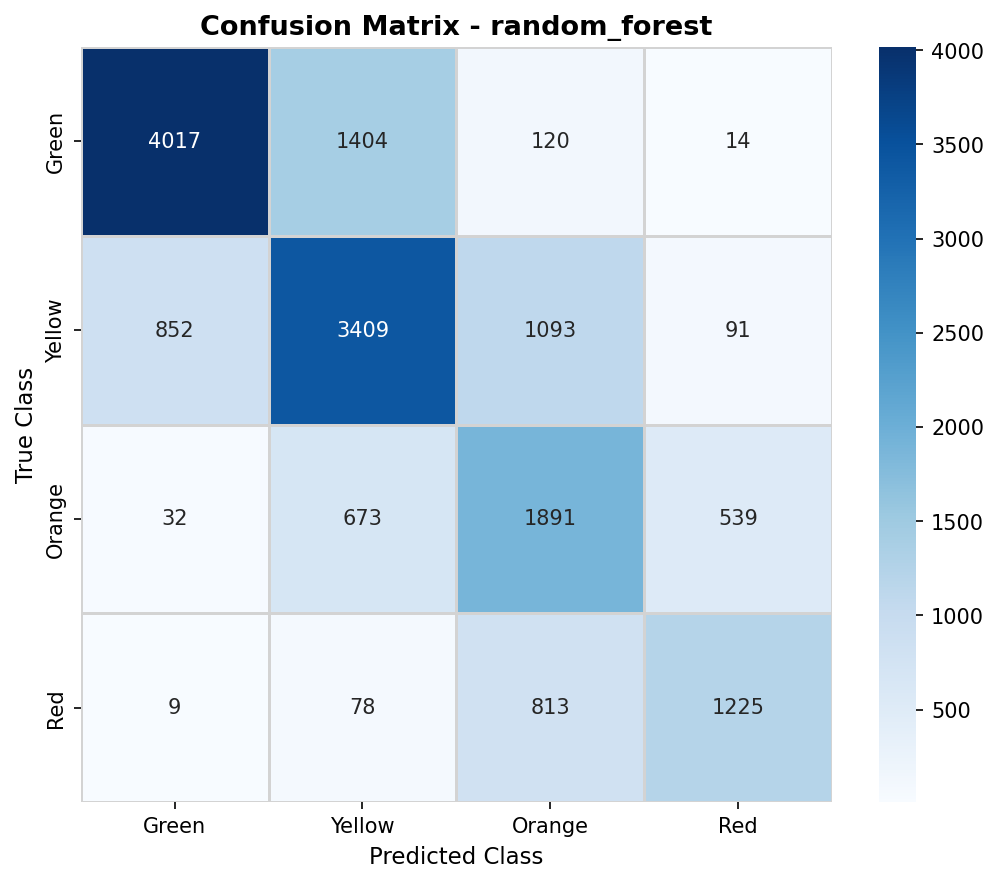

**xgboost_confusion_matrix.png**

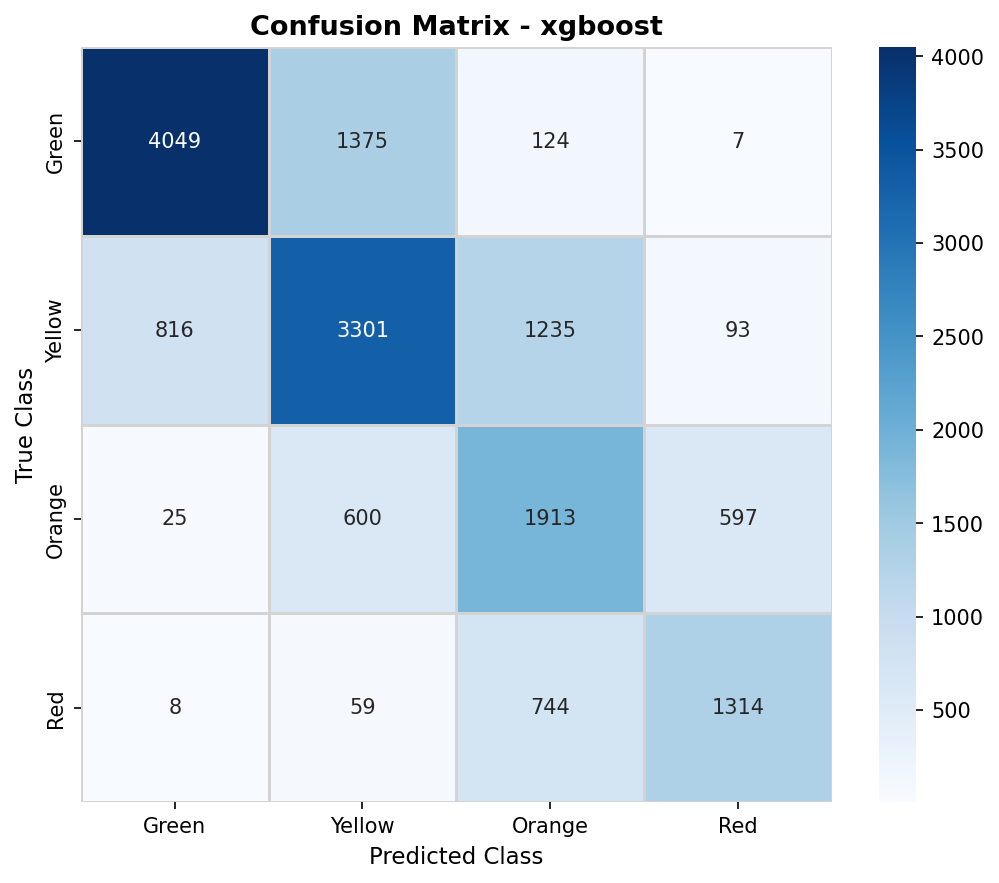

**regression_to_class_xgboost_confusion_matrix.png**

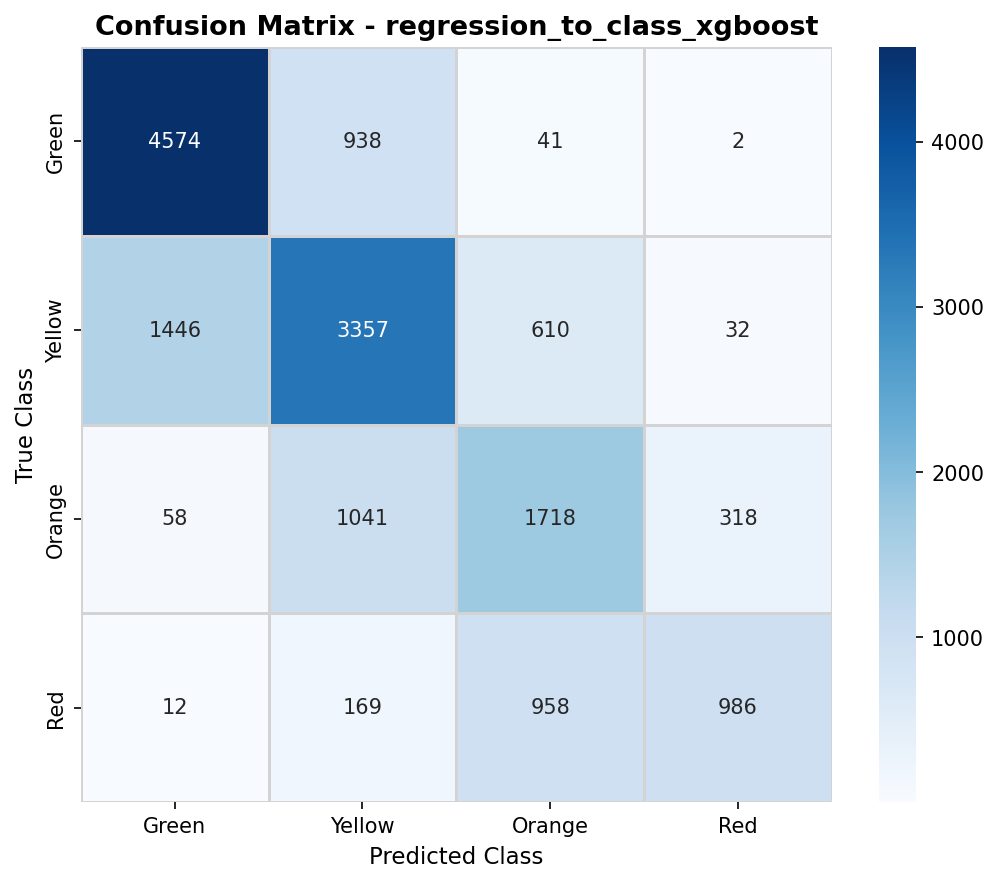

**xgboost_ordinal_confusion_matrix.png**

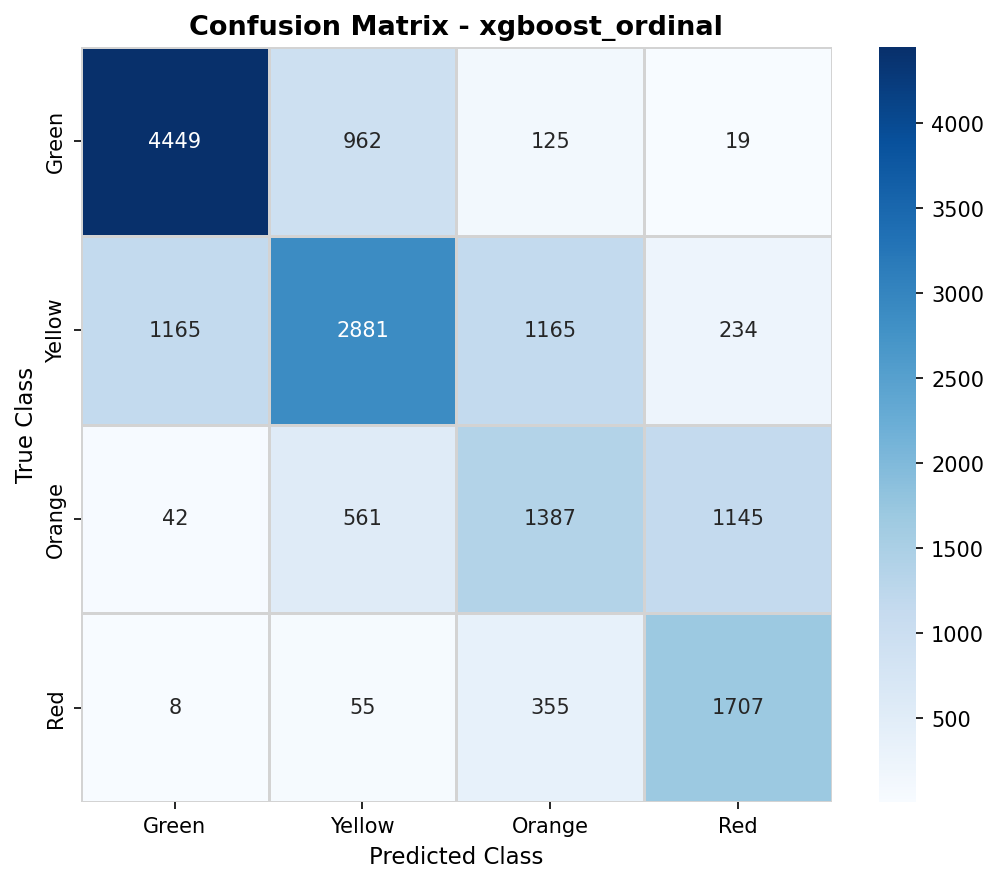

**classifier_xgboost_calibrated_confusion_matrix.png**

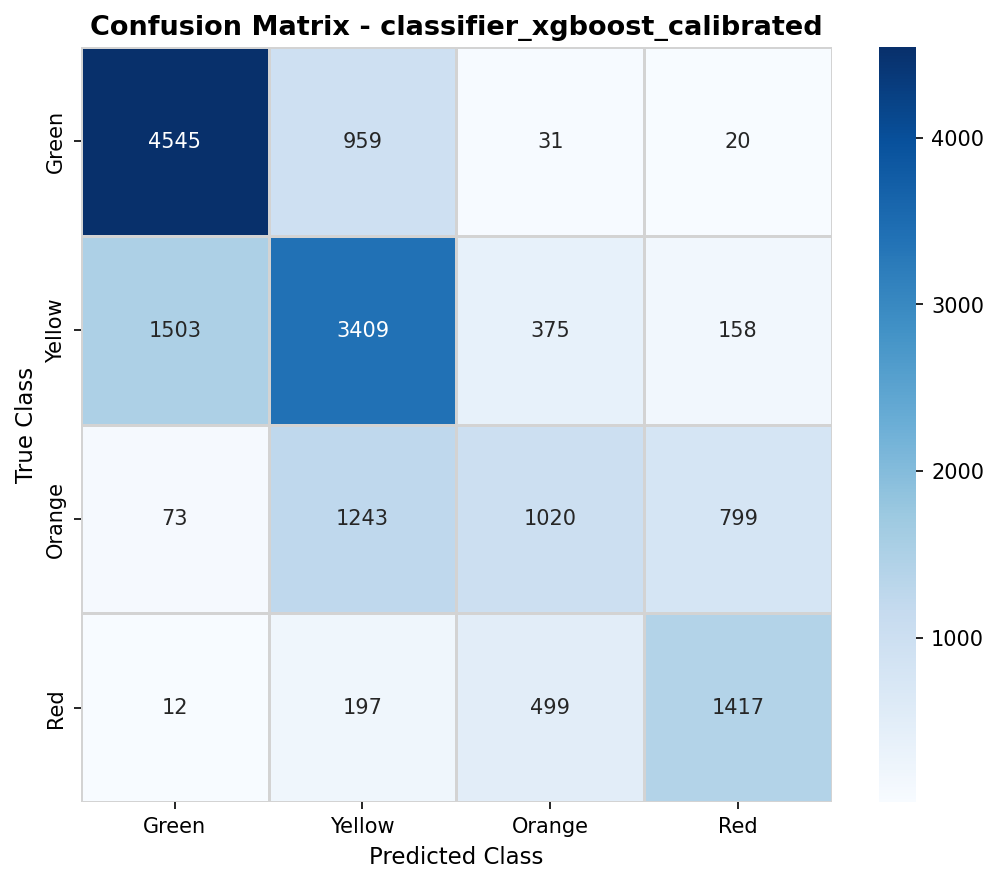

**hybrid_xgboost_reg_xgboost_cls_confusion_matrix.png**

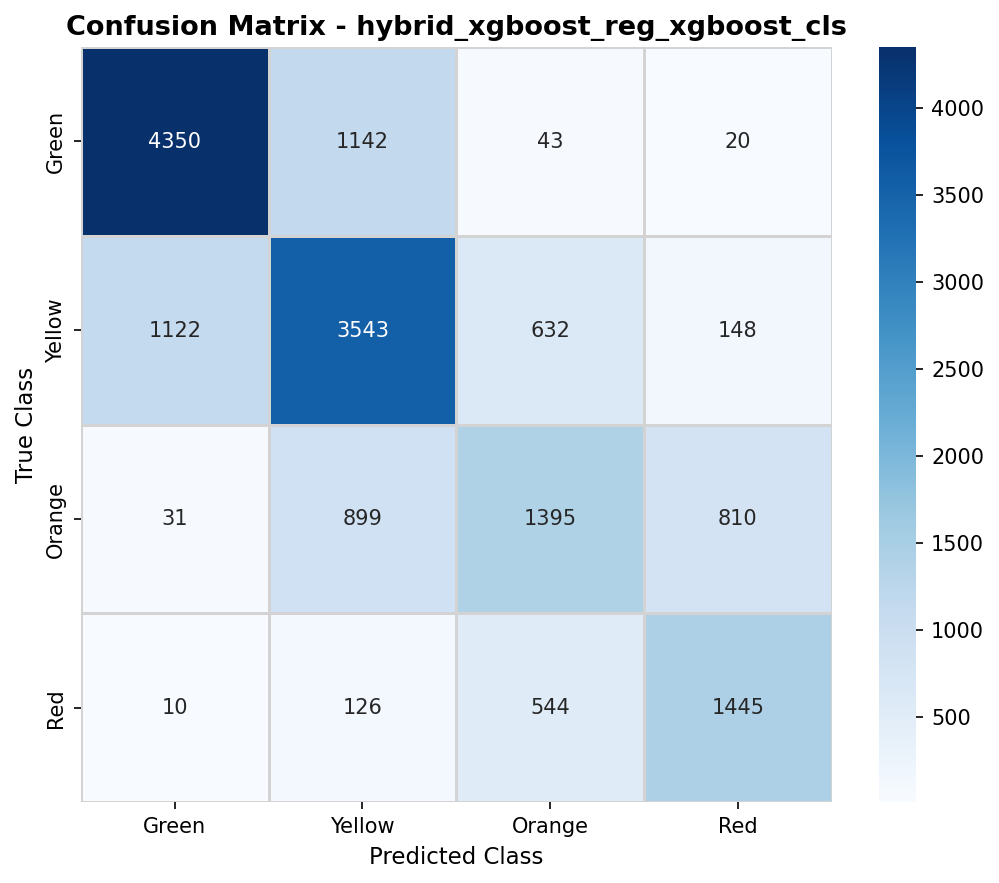

In [11]:
# Confusion matrices for every strategy (test set), final hybrid last
for strategy in (
    "logistic_regression",
    "random_forest",
    "xgboost",
    "regression_to_class_xgboost",
    "xgboost_ordinal",
    "classifier_xgboost_calibrated",
    "hybrid_xgboost_reg_xgboost_cls",
):
    show_plot(CLS_PLOTS_DIR / f"{strategy}_confusion_matrix.png", width=700)

**logistic_regression_permutation_importance.png**

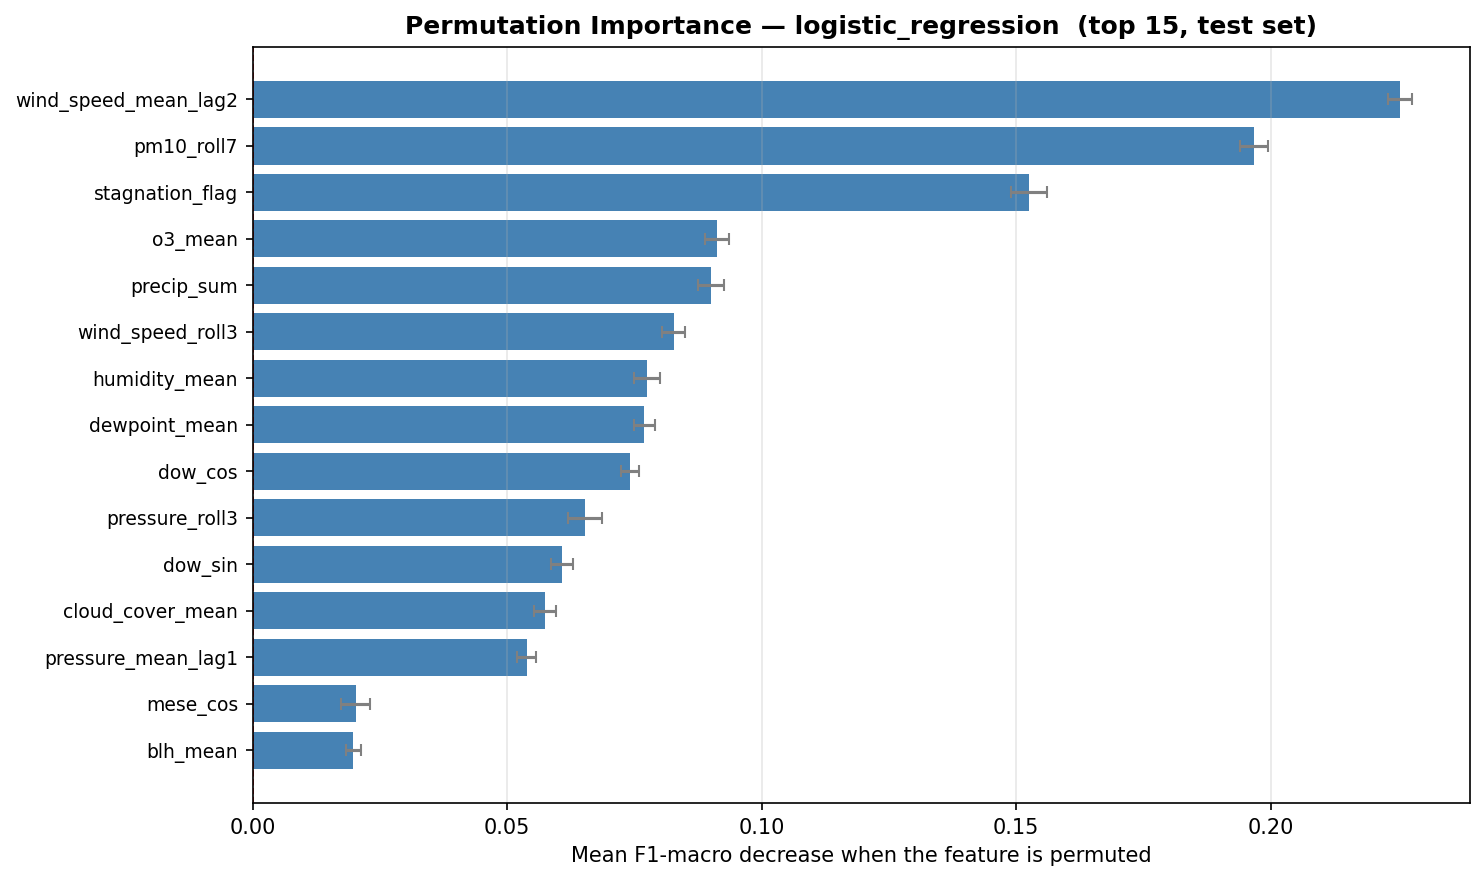

**random_forest_permutation_importance.png**

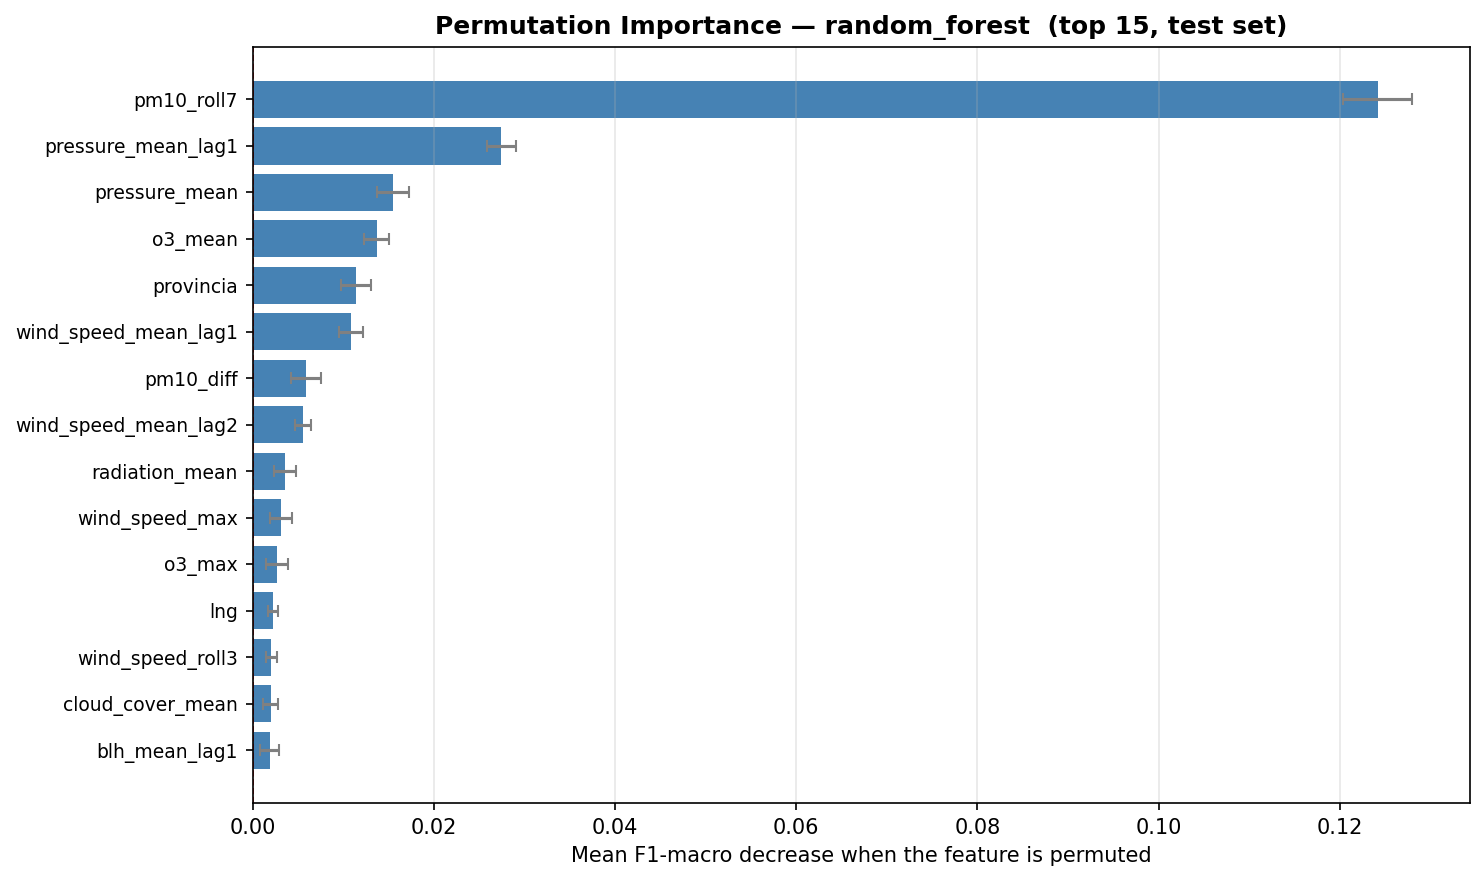

**xgboost_permutation_importance.png**

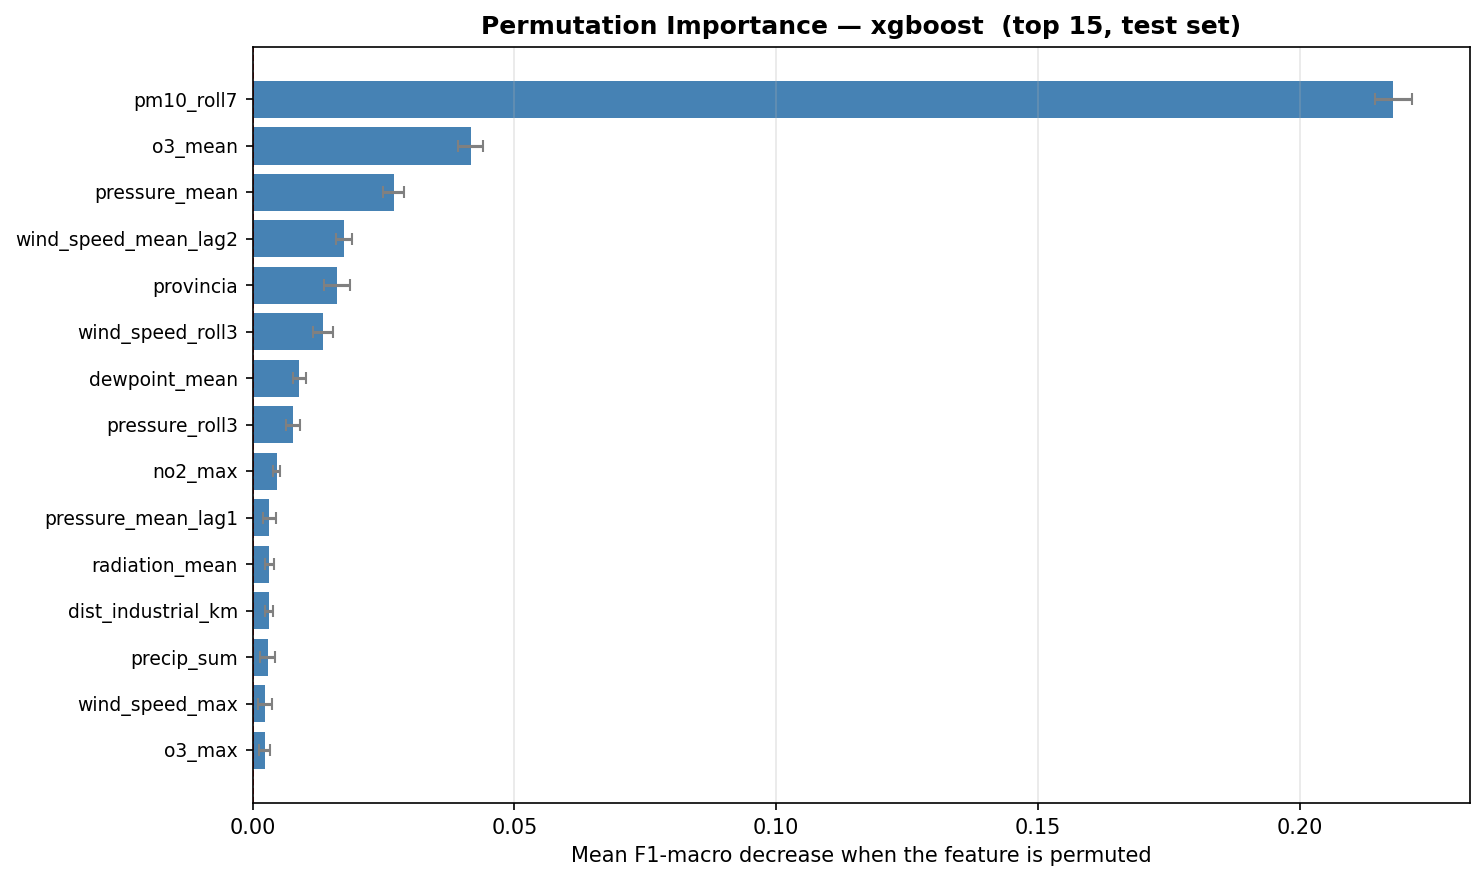

**xgboost_ordinal_permutation_importance.png**

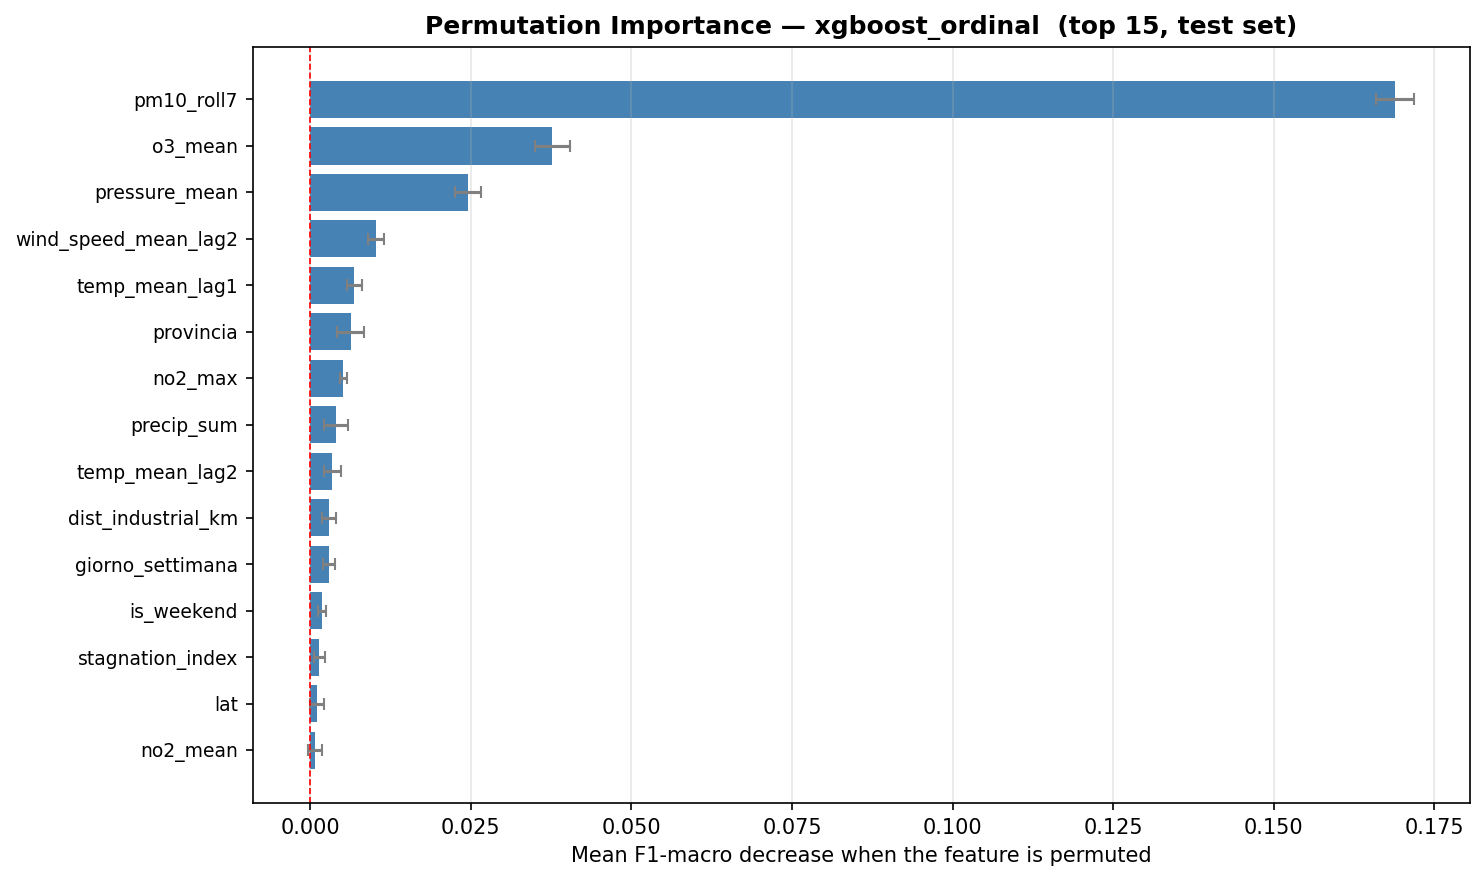

In [12]:
# Permutation importance for the base classifiers and the ordinal model
for strategy in ("logistic_regression", "random_forest", "xgboost", "xgboost_ordinal"):
    show_plot(CLS_PLOTS_DIR / f"{strategy}_permutation_importance.png")

**xgboost_hybrid_reliability_diagram_before_after.png**

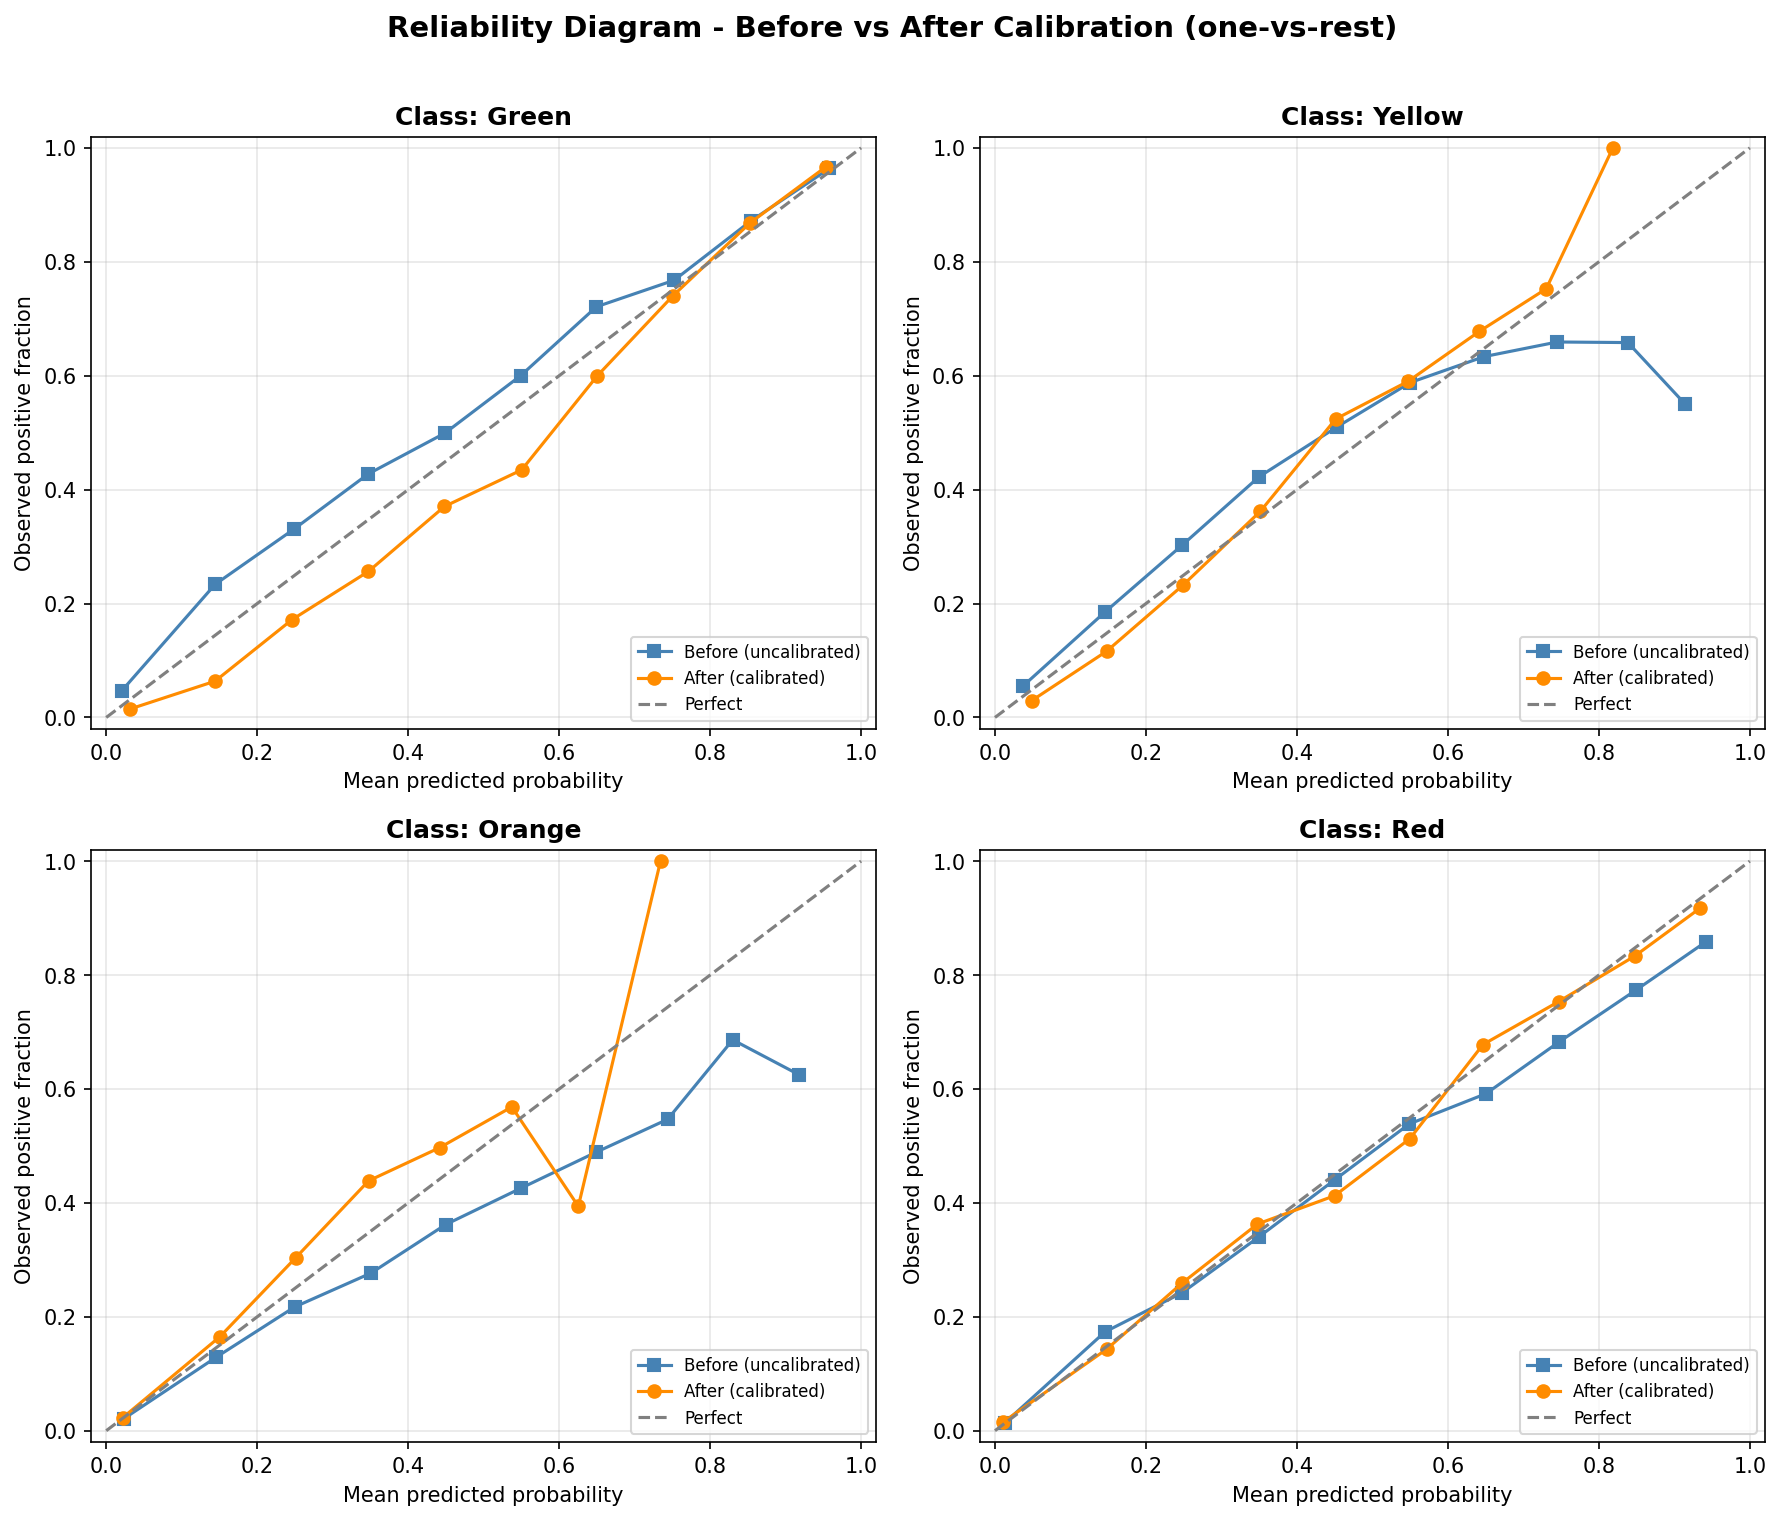

In [13]:
# Effect of isotonic calibration on the hybrid's classifier (reliability diagram)
show_plot(CLS_PLOTS_DIR / "xgboost_hybrid_reliability_diagram_before_after.png")

## Section 7 — Forecast Demo (REST API)

Live call to `GET /forecast?station_id=...&days=1` on the FastAPI service
(start it first with `python -m uvicorn api.main:app --port 8000`).

The endpoint enforces a **data-freshness guardrail**: if a station has fewer than 3 valid
PM10 days in the last 7 (rolling window on GCS), it responds `422` instead of producing an
unreliable forecast. The cell tries station 501 and, if its recent data is insufficient,
automatically falls back to the first station with fresh data.

In [14]:
health = requests.get(f"{API_BASE}/health", timeout=10)
health.raise_for_status()
print("API health:", health.json())

def try_forecast(station_id: str) -> requests.Response:
    return requests.get(f"{API_BASE}/forecast", params={"station_id": station_id, "days": 1}, timeout=120)

response = try_forecast("501")
if response.status_code == 422:
    print(f"Station 501 -> 422 (data-freshness guardrail): {response.json()['detail']}")
    print("Falling back to the first station with enough recent data...")
    stations = requests.get(f"{API_BASE}/stations", timeout=30).json()
    for station in stations:
        response = try_forecast(station["idstazione"])
        if response.status_code == 200:
            break

response.raise_for_status()
forecast = response.json()
print(f"\nForecast for {forecast['station_name']} (id {forecast['station_id']}):")
print(json.dumps(forecast, indent=2, ensure_ascii=False))

API health: {'status': 'ok'}
Station 501 -> 422 (data-freshness guardrail): Insufficient recent data for a reliable forecast (valid_days=2 < 3).
Falling back to the first station with enough recent data...



Forecast for Sondrio v.Paribelli (id 1264):
{
  "station_id": "1264",
  "station_name": "Sondrio v.Paribelli",
  "predictions": [
    {
      "date": "2026-07-07",
      "pm10_predicted": 10.26,
      "alert_class": "verde",
      "alert_index": 0,
      "alert_source": "regression",
      "weather_used": {
        "temp_mean": 18.345833333333335,
        "wind_speed_mean": 8.854166666666666,
        "boundary_layer_height_mean": 1041.25
      },
      "model_drivers": {
        "temp_mean": 18.345833333333335,
        "pm10_lag1": 7.0,
        "pm10_lag2": 7.0,
        "pm10_roll3": 7.0,
        "pm10_roll7": 9.0,
        "pm10_diff": 0.0,
        "pressure_mean": 848.7166666666667,
        "pressure_mean_lag1": null,
        "wind_speed_mean": 8.854166666666666,
        "wind_speed_max": 18.9,
        "wind_speed_roll3": null,
        "blh_mean": 1041.25,
        "blh_min": 10.0,
        "precip_sum": 0.0,
        "stagnation_index": 0.011294117647058824,
        "stagnation_flag": 

## Section 8 — Conclusions

### Headline results

| Task | Final model | Primary metric | Value |
|---|---|---|---|
| PM10 regression | XGBoost | R² / RMSE | 0.696 / 9.24 µg/m³ |
| Alert classification | Hybrid XGBoost (reg + calibrated cls) | F1-macro / recall_rosso | 0.636 / 0.680 |
| Station clustering | KMeans (k=2) | Silhouette | 0.467 |

### Model limitations

| Phenomenon | Capturable? | Notes |
|---|---|---|
| PM10 persistence / autocorrelation | ✅ Yes | Lag and rolling features are the dominant predictors |
| Atmospheric stagnation (winter inversions) | ✅ Yes | `stagnation_index`, BLH, pressure, wind |
| Seasonality and weekly cycle | ✅ Yes | Cyclic encoding + `heating_season` |
| Industrial / orographic exposure | ✅ Partially | `dist_industrial_km`, `quota` — static, not dynamic |
| Exceptional events (Saharan dust transport, wildfires, New Year's fireworks) | ❌ No | No feature represents them: they are the `rosso` peaks with the highest RMSE (17.8 µg/m³) |
| Episodic local emissions (construction sites, anomalous traffic) | ❌ No | Not observed by any data source |
| Compounded error on the 2-day horizon | ⚠️ Structural | The day-2 forecast uses the day-1 predicted PM10 as its lag |
| Stations with sparse recent data | ⚠️ Handled downstream | API 422 guardrail (`valid_days_last_7 < 3`) instead of predicting blindly |

### Possible future improvements

1. **Exogenous features for exceptional events**: dust-transport indices (e.g. CAMS dust
   forecast) to capture Saharan episodes; holiday calendar for fireworks.
2. **Sequence models** (LSTM/TFT) to exploit the full recent history instead of fixed lags.
3. **Quantile regression / conformal prediction** for confidence intervals around the forecast,
   more useful than a point estimate for alerting purposes.
4. **Recall rosso**: the ordinal model reaches 0.803 but violates the severe_error_rate
   constraint — a hybrid-ordinal ensemble with per-class thresholds could improve the trade-off.
5. **Larger training set**: two full winters are few for the `rosso` class (13% of samples);
   every additional winter improves the right tail of the distribution.